# Test for Histogram Facet (Template version)

**Date: 04-03-2026**

**Last Update: 04-17-2026**

## Introduction

- This notebook is a lighter test for developers to test **feat/histogram-facet** functions using results from lymphnode_analysis workbook in "../paper/example/lymphnode_analysis.ipynb". 
- This notebook tests functions from **templates** only.

### How to use this notebook for testing

- Make a copy of the notebook in your test branch.
- Pull your code into the branch.
- Make sure the kernel is set as the python environment created from environmental.yml
- Write your own testing cells for functions from template.
- Run cells from top to bottom.

### Dataset Overview
We use the final result from the lymphnode_analysis.ipynb, which is stored in "../data/dev_example.pickle"

Below is the overview of the original dataset
- **Source**: This example uses scimap demo dataset (https://scimap.xyz/tutorials/md/demo_data_scimap/), with additional annotations added for phenotyping analysis named as "example_lymphnode_data.csv". The original data is publicly available normal human lymph node tissue microarray data from CyCIF imaging, preprocessed by MCMICRO. No additional ethical approvals are required for this de-identified published dataset. 
- **Size**: 4,825 cells
- **Markers**: 33 protein markers

## Define Input/Output Paths

In [1]:
# Setup file paths
data_pickle = "../data/dev_example.pickle"

## Auto-Reload Code Changes

In [2]:
%load_ext autoreload
%autoreload 2

## Step Y: Histogram Facet Tests (Template Method)

### Y.1 Test 'together' mode

- feature="CD21"
- group_by="broad_cell_type"
- together=True
- bins="auto"

2026-04-19 22:28:43,579 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:43,606 - INFO - Displaying top 10 rows of histogram dataframe:


   count  bin_left  bin_right  bin_center broad_cell_type
0      0  6.483555   6.610507    6.547031         B Cells
1      0  6.610507   6.737459    6.673983         B Cells
2      0  6.737459   6.864411    6.800935         B Cells
3      2  6.864411   6.991363    6.927887         B Cells
4      1  6.991363   7.118315    7.054839         B Cells
5      6  7.118315   7.245267    7.181791         B Cells
6     13  7.245267   7.372219    7.308743         B Cells
7     16  7.372219   7.499171    7.435695         B Cells
8     28  7.499171   7.626123    7.562647         B Cells
9     38  7.626123   7.753075    7.689599         B Cells


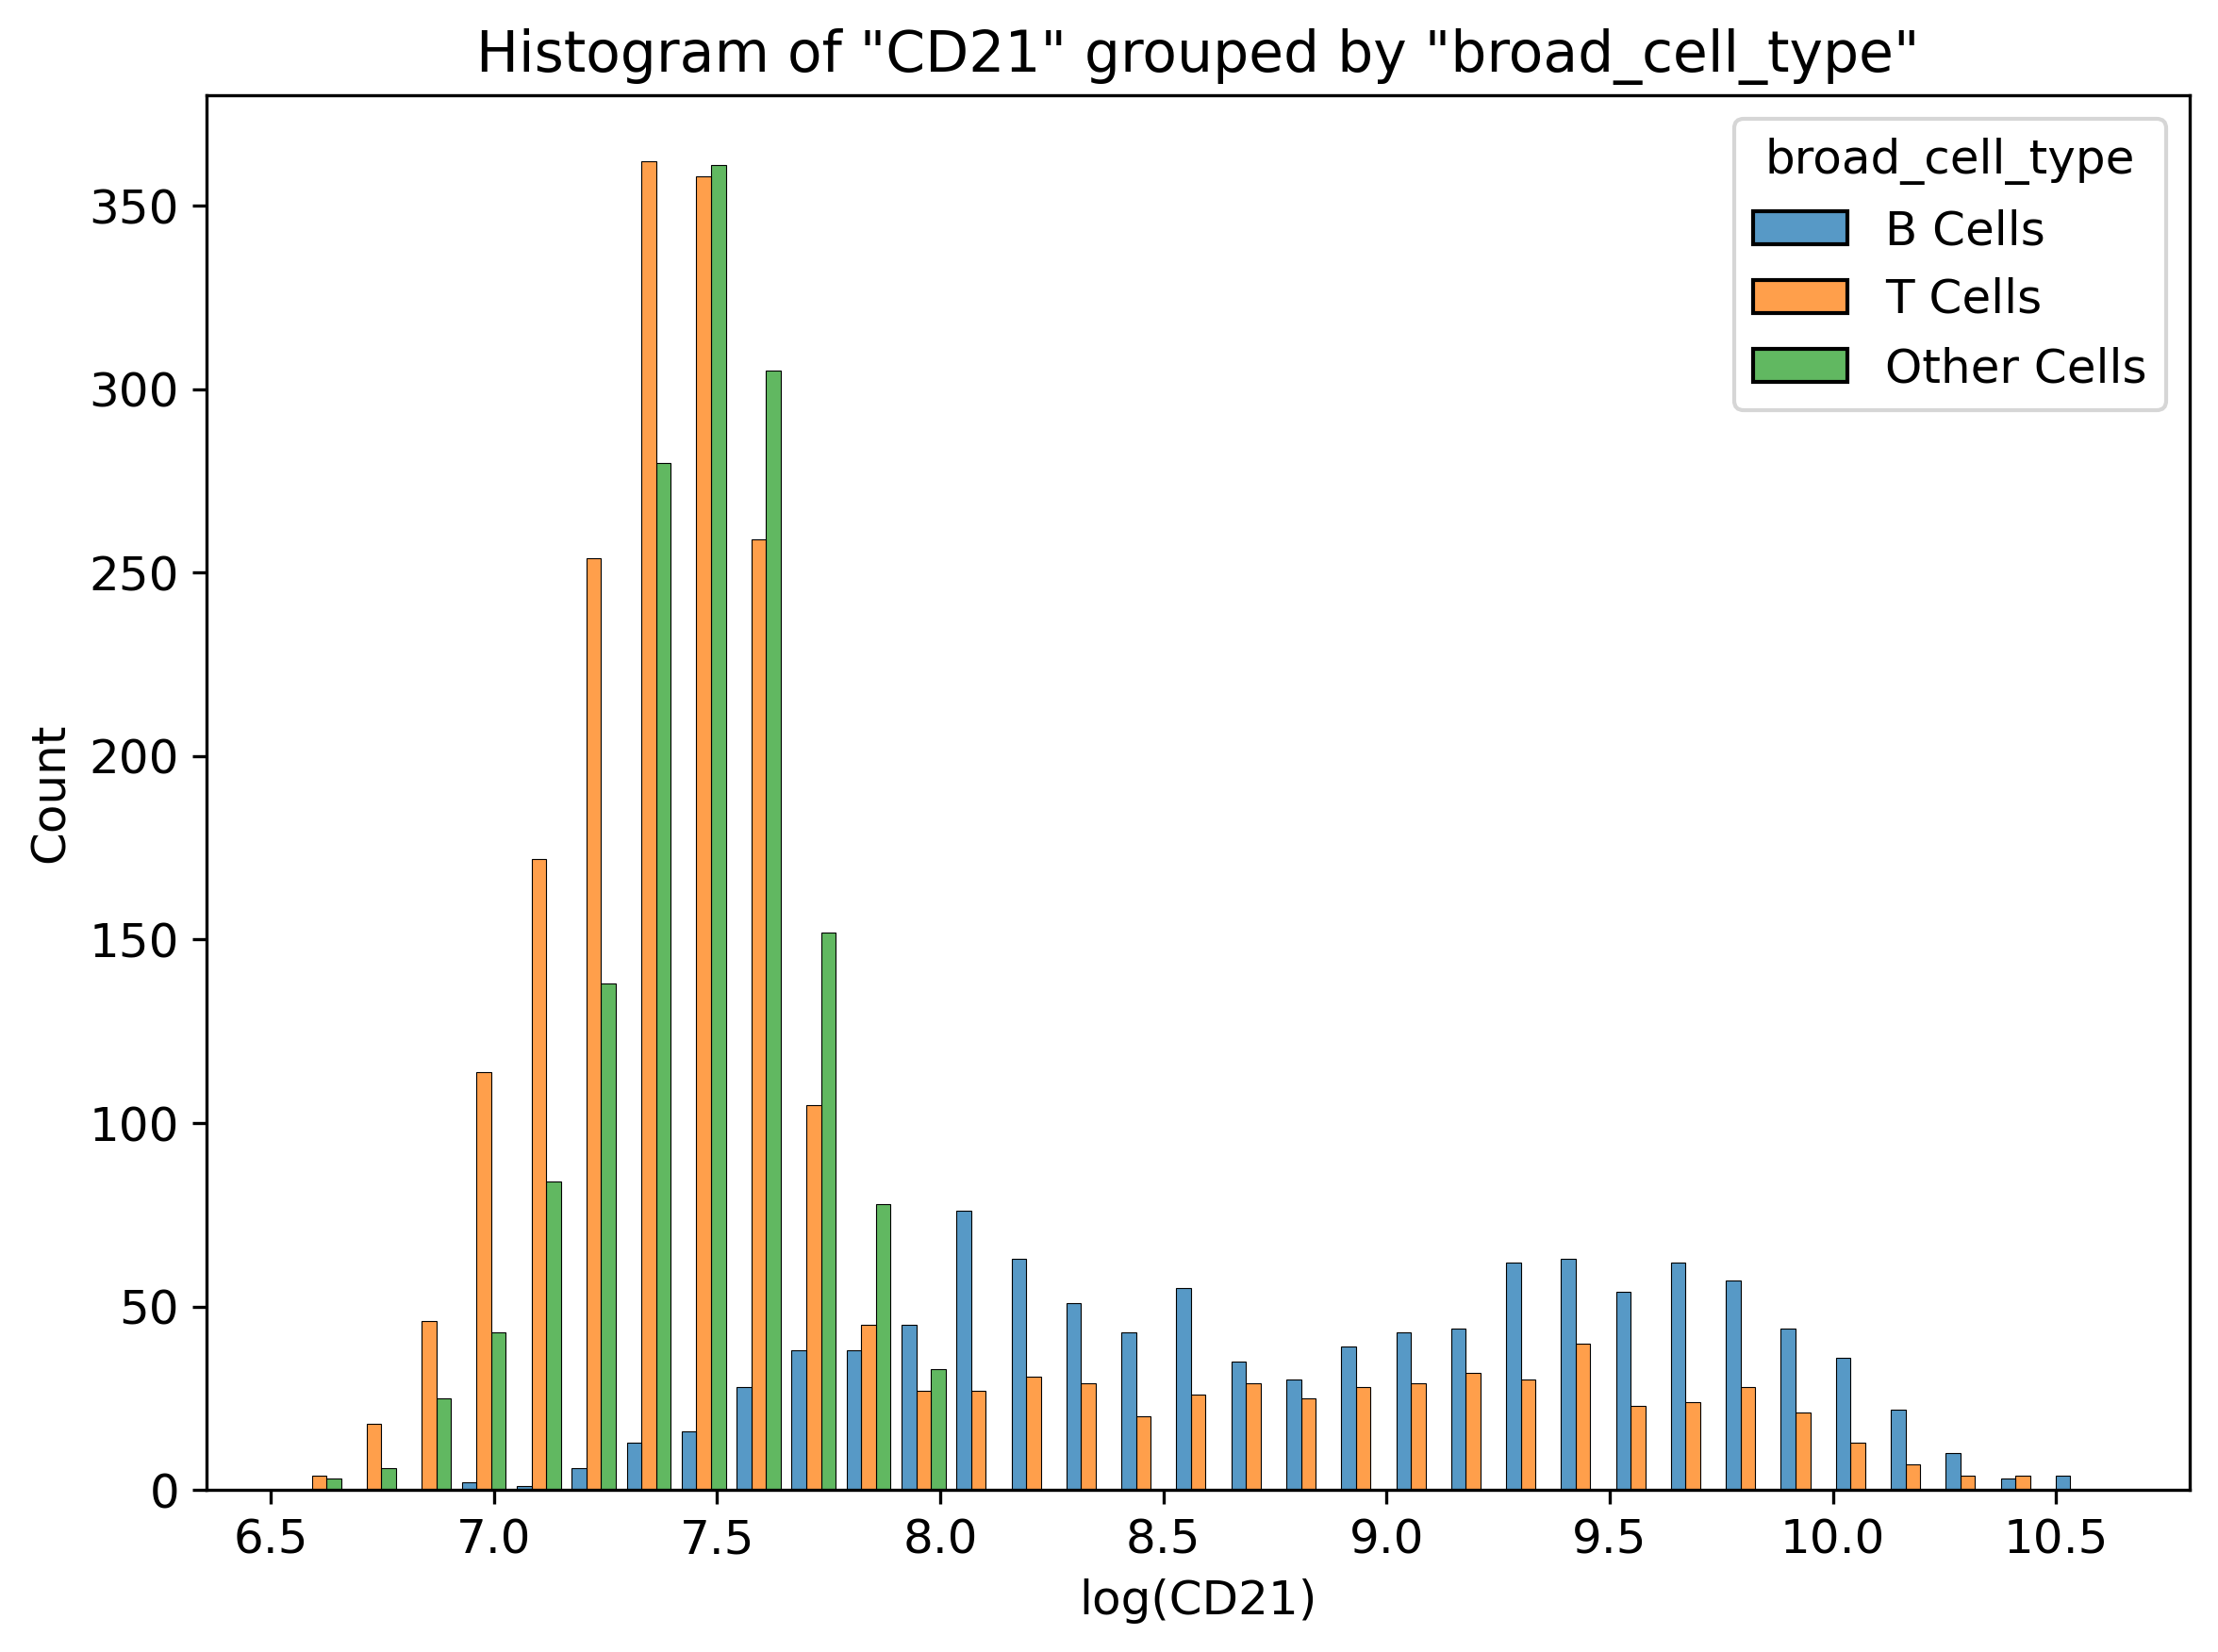

2026-04-19 22:28:43,762 - INFO - Returning figure and dataframe for in-memory use


In [3]:
# Create histogram for CD21 expression by cell type

from spac.templates.histogram_template import run_from_json

params = {
    "Upstream_Analysis": data_pickle,
    "Feature": "CD21",
    "Group_by": "broad_cell_type",
    "Table_": "Original",
    "Together": True,
    "Take_X_Log": True,
    "Take_Y_Log": False,
    "Multiple": "dodge",
    "Shrink_Number": 0.8,
    "Bins": "auto",
    "Bin_Transparency": 0.75,
    "Stat": "count",
    "Plot_By": "Feature"
}

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.2 Test 'Not together' mode

- feature="CD21"
- group_by="broad_cell_type"
- together=True->False
- bins="auto"

2026-04-19 22:28:43,808 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.
2026-04-19 22:28:43,923 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:43,924 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:43,924 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:43,958 - INFO - Displaying top 10 rows of histogram dataframe:


   count  bin_left  bin_right  bin_center
0      2  6.483555   6.527780    6.505668
1      1  6.527780   6.572006    6.549893
2      0  6.572006   6.616231    6.594118
3      2  6.616231   6.660456    6.638344
4      2  6.660456   6.704682    6.682569
5      4  6.704682   6.748907    6.726794
6      3  6.748907   6.793132    6.771020
7     13  6.793132   6.837357    6.815245
8     11  6.837357   6.881583    6.859470
9     16  6.881583   6.925808    6.903695


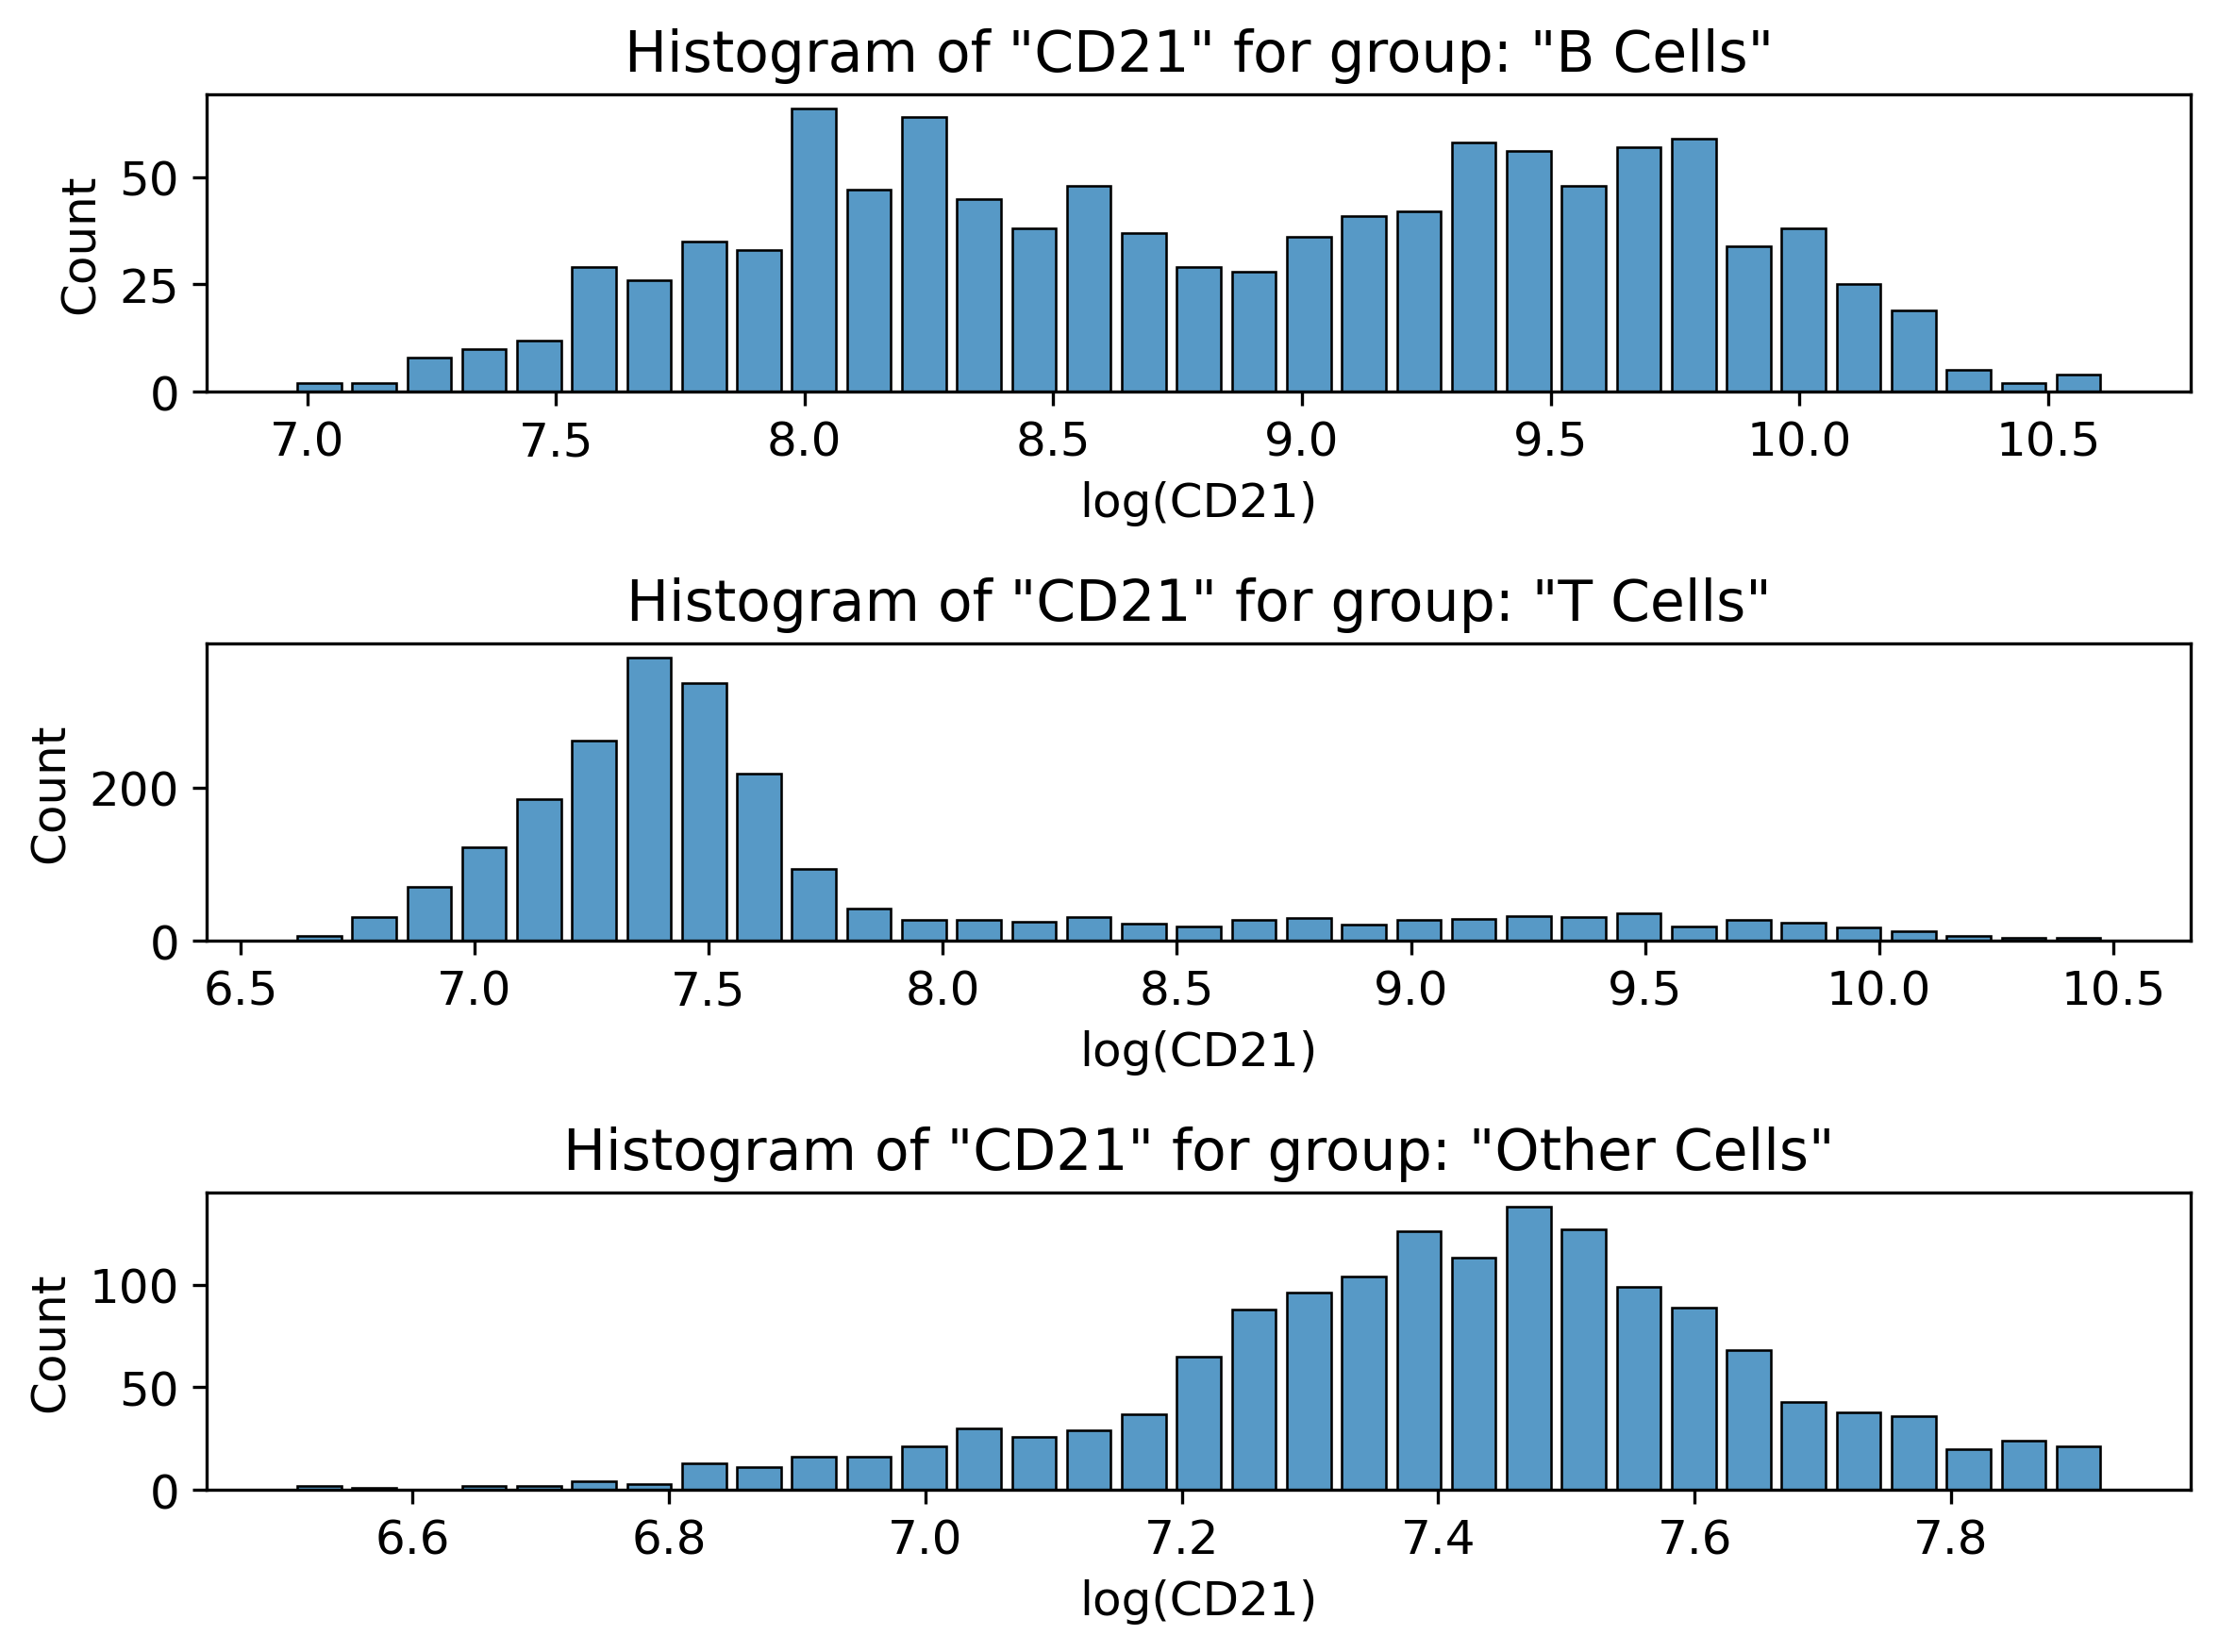

2026-04-19 22:28:44,132 - INFO - Returning figure and dataframe for in-memory use


In [4]:
params["Together"] = False

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.3 Test 'facet' mode

- feature="CD21"
- group_by="broad_cell_type"
- together=False
- bins="auto"
- facet=None->True
- facet_ncol=None->2

2026-04-19 22:28:44,159 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.
2026-04-19 22:28:44,311 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:44,312 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:44,312 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:44,338 - INFO - Displaying top 10 rows of histogram dataframe:


         CD25         CD2         CD10       CD163         CD3D          CD5  \
0  581.581197  618.384615  1606.777778  509.324786   477.589744  1795.410256   
1  565.893204  442.291262  1539.398058  496.825243   484.902913  1793.932039   
2  666.475000  574.333333  1759.683333  548.050000   494.166667  1901.141667   
3  558.503356  408.577181  1557.738255  472.369127   347.093960  1772.805369   
4  562.000000  524.455090  1596.982036  482.065868   372.898204  1808.514970   
5  558.549419  536.395349  1500.401163  489.200581   665.761628  1770.860465   
6  599.720497  806.130435  1759.869565  499.621118   911.291926  1789.795031   
7  563.401575  713.960630  1450.149606  476.000000  1631.606299  1743.488189   
8  584.614841  658.671378  1525.837456  523.844523   819.522968  1771.459364   
9  585.398551  611.376812  1588.652174  519.594203   448.572464  1822.485507   

          CD30        ACTIN         CD45        CD206  ...         CD15  \
0  1084.051282  5382.076923  2983.239316  11

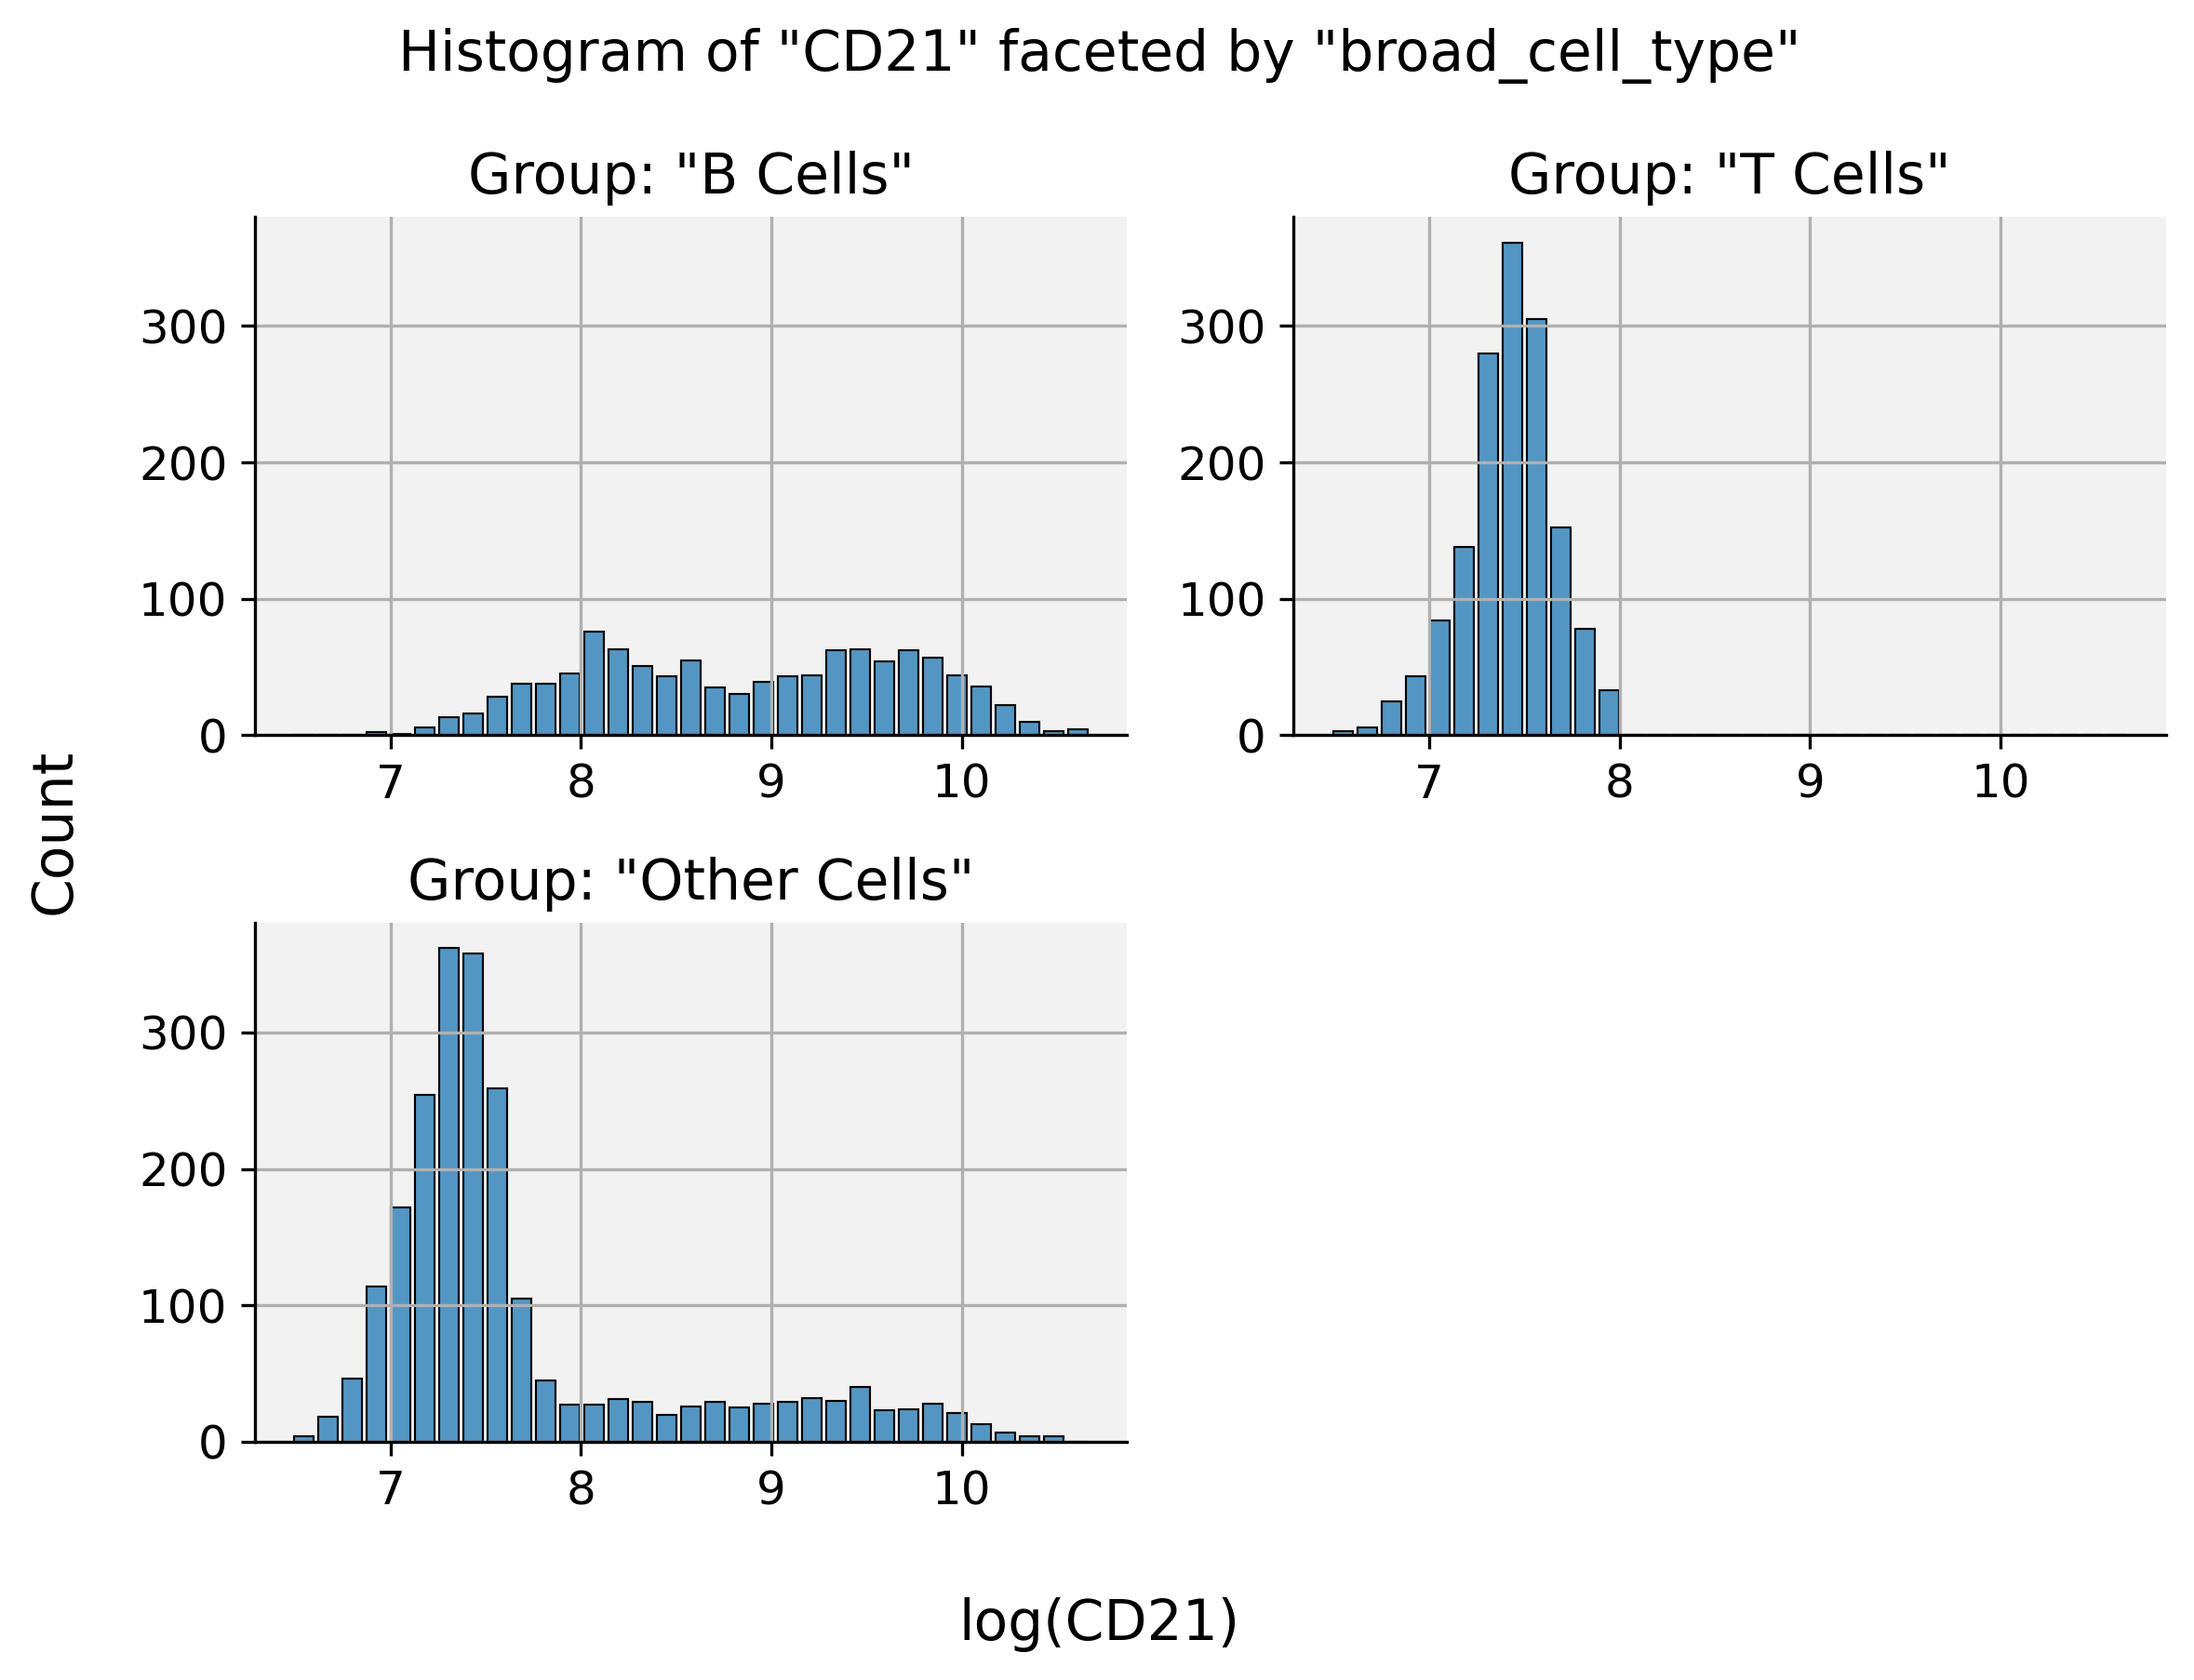

2026-04-19 22:28:44,500 - INFO - Returning figure and dataframe for in-memory use


In [5]:
params["Facet"] = True
params["Facet_Ncol"] = 2

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.4 Test 'bins' in facet mode

- feature="CD21"
- group_by="broad_cell_type"
- together=False
- bins="auto"->15
- facet=True
- facet_ncol=2

2026-04-19 22:28:44,528 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.
2026-04-19 22:28:44,668 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:44,668 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:44,669 - INFO - Plotting Feature: "CD21"
2026-04-19 22:28:44,694 - INFO - Displaying top 10 rows of histogram dataframe:


         CD25         CD2         CD10       CD163         CD3D          CD5  \
0  581.581197  618.384615  1606.777778  509.324786   477.589744  1795.410256   
1  565.893204  442.291262  1539.398058  496.825243   484.902913  1793.932039   
2  666.475000  574.333333  1759.683333  548.050000   494.166667  1901.141667   
3  558.503356  408.577181  1557.738255  472.369127   347.093960  1772.805369   
4  562.000000  524.455090  1596.982036  482.065868   372.898204  1808.514970   
5  558.549419  536.395349  1500.401163  489.200581   665.761628  1770.860465   
6  599.720497  806.130435  1759.869565  499.621118   911.291926  1789.795031   
7  563.401575  713.960630  1450.149606  476.000000  1631.606299  1743.488189   
8  584.614841  658.671378  1525.837456  523.844523   819.522968  1771.459364   
9  585.398551  611.376812  1588.652174  519.594203   448.572464  1822.485507   

          CD30        ACTIN         CD45        CD206  ...         CD15  \
0  1084.051282  5382.076923  2983.239316  11

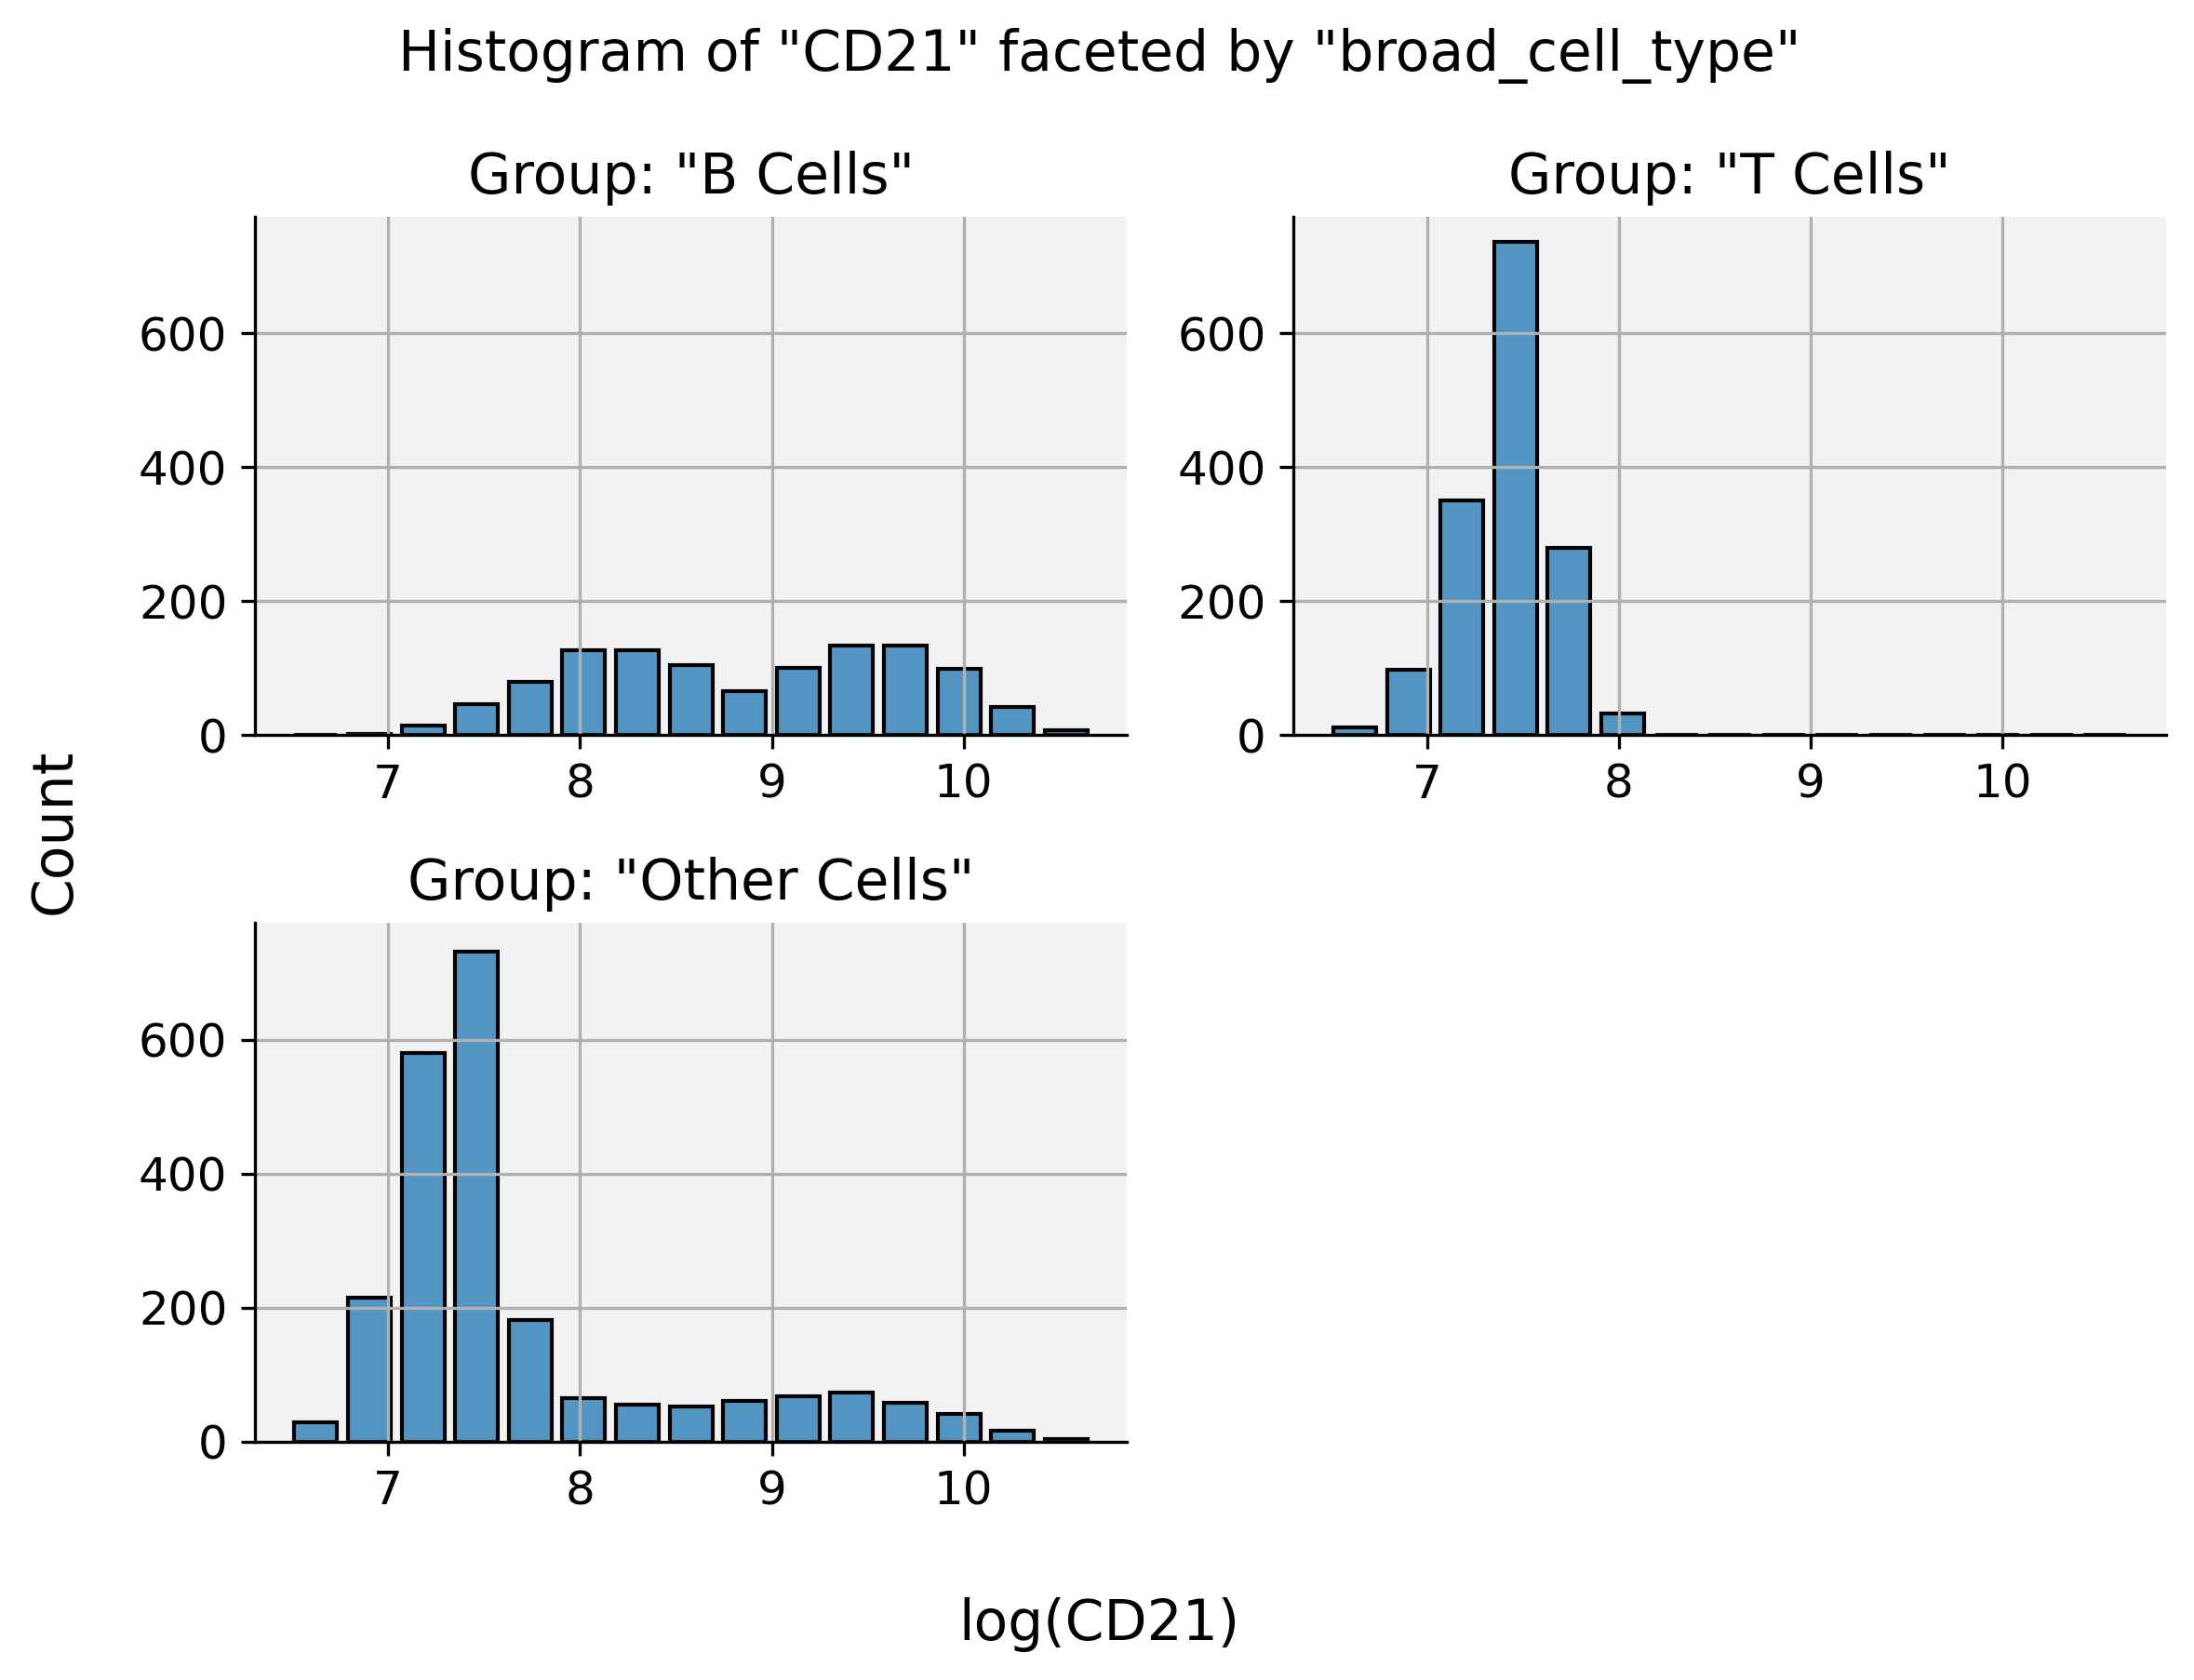

2026-04-19 22:28:44,845 - INFO - Returning figure and dataframe for in-memory use


In [6]:
params["Bins"] = 15

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.5 Test categorical annotation + x-label rotation

- feature="CD21"->None
- annotation=None->"detailed_cell_type"
- group_by="broad_cell_type"
- together=False
- bins=15
- x_rotate=0->45
- histplot_by="Feature"->"Annotation"
- facet=True
- facet_ncol=2

2026-04-19 22:28:44,951 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:44,951 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:44,952 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.
2026-04-19 22:28:45,143 - INFO - Displaying top 10 rows of histogram dataframe:


Automatically calculated number of bins is: 33
         CD25         CD2         CD10       CD163         CD3D          CD5  \
0  581.581197  618.384615  1606.777778  509.324786   477.589744  1795.410256   
1  565.893204  442.291262  1539.398058  496.825243   484.902913  1793.932039   
2  666.475000  574.333333  1759.683333  548.050000   494.166667  1901.141667   
3  558.503356  408.577181  1557.738255  472.369127   347.093960  1772.805369   
4  562.000000  524.455090  1596.982036  482.065868   372.898204  1808.514970   
5  558.549419  536.395349  1500.401163  489.200581   665.761628  1770.860465   
6  599.720497  806.130435  1759.869565  499.621118   911.291926  1789.795031   
7  563.401575  713.960630  1450.149606  476.000000  1631.606299  1743.488189   
8  584.614841  658.671378  1525.837456  523.844523   819.522968  1771.459364   
9  585.398551  611.376812  1588.652174  519.594203   448.572464  1822.485507   

          CD30        ACTIN         CD45        CD206  ...         CD15 

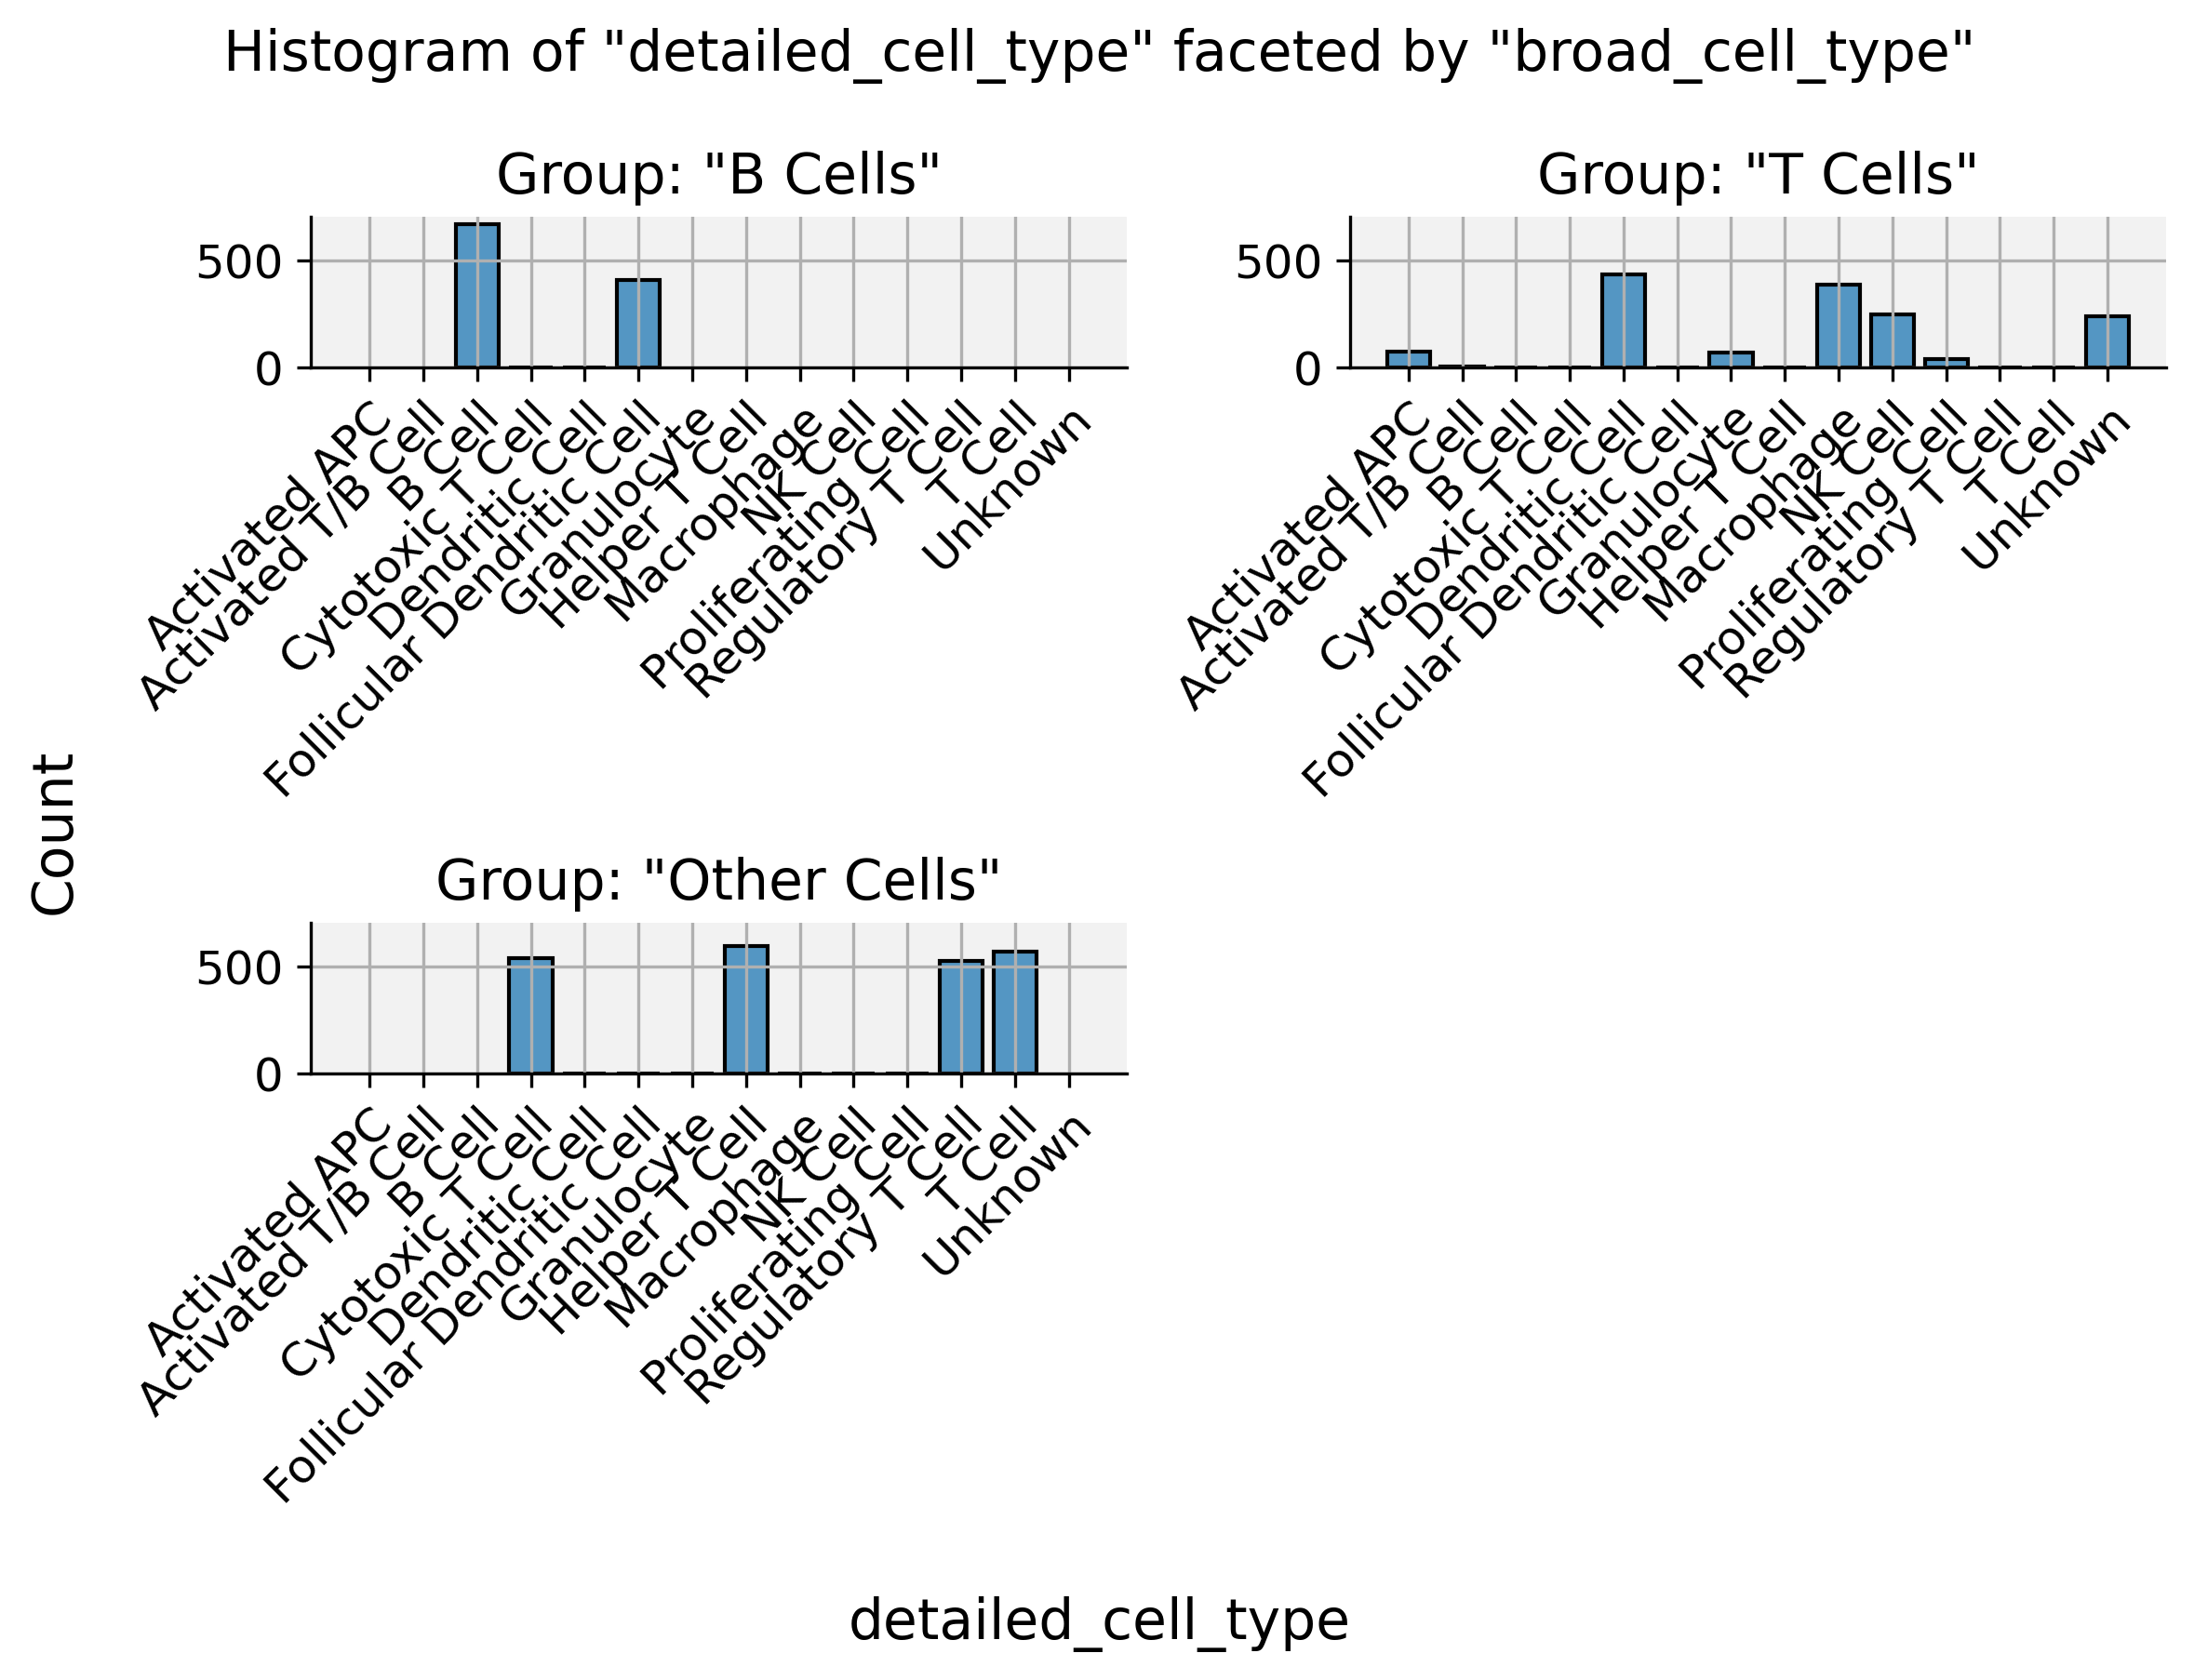

2026-04-19 22:28:45,382 - INFO - Returning figure and dataframe for in-memory use


In [7]:
params.pop("Feature")
params["Annotation"] = "detailed_cell_type"
params["X_Axis_Label_Rotation"] = 45
params["Plot_By"] = "Annotation"

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

- annotation="detailed_cell_type"
- group_by="broad_cell_type"
- together=False
- bins=15
- x_rotate=45
- histplot_by="Annotation"
- facet=True->False
- facet_ncol=2

2026-04-19 22:28:45,418 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:45,418 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:45,419 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.
/Users/bojohnzhang/Documents/GitHub/zhan4329@purdue.edu/SCSAWorkflow-2025/src/spac/templates/histogram_template.py:382: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
2026-04-19 22:28:45,513 - INFO - Displaying top 10 rows of histogram dataframe:


Automatically calculated number of bins is: 33
                  bin_center                   bin_left  \
0              Activated APC              Activated APC   
1         Activated T/B Cell         Activated T/B Cell   
2                     B Cell                     B Cell   
3           Cytotoxic T Cell           Cytotoxic T Cell   
4             Dendritic Cell             Dendritic Cell   
5  Follicular Dendritic Cell  Follicular Dendritic Cell   
6                Granulocyte                Granulocyte   
7              Helper T Cell              Helper T Cell   
8                 Macrophage                 Macrophage   
9                    NK Cell                    NK Cell   

                   bin_right  count  
0              Activated APC     74  
1         Activated T/B Cell      4  
2                     B Cell      0  
3           Cytotoxic T Cell      0  
4             Dendritic Cell    438  
5  Follicular Dendritic Cell      0  
6                Granulocyte     72  

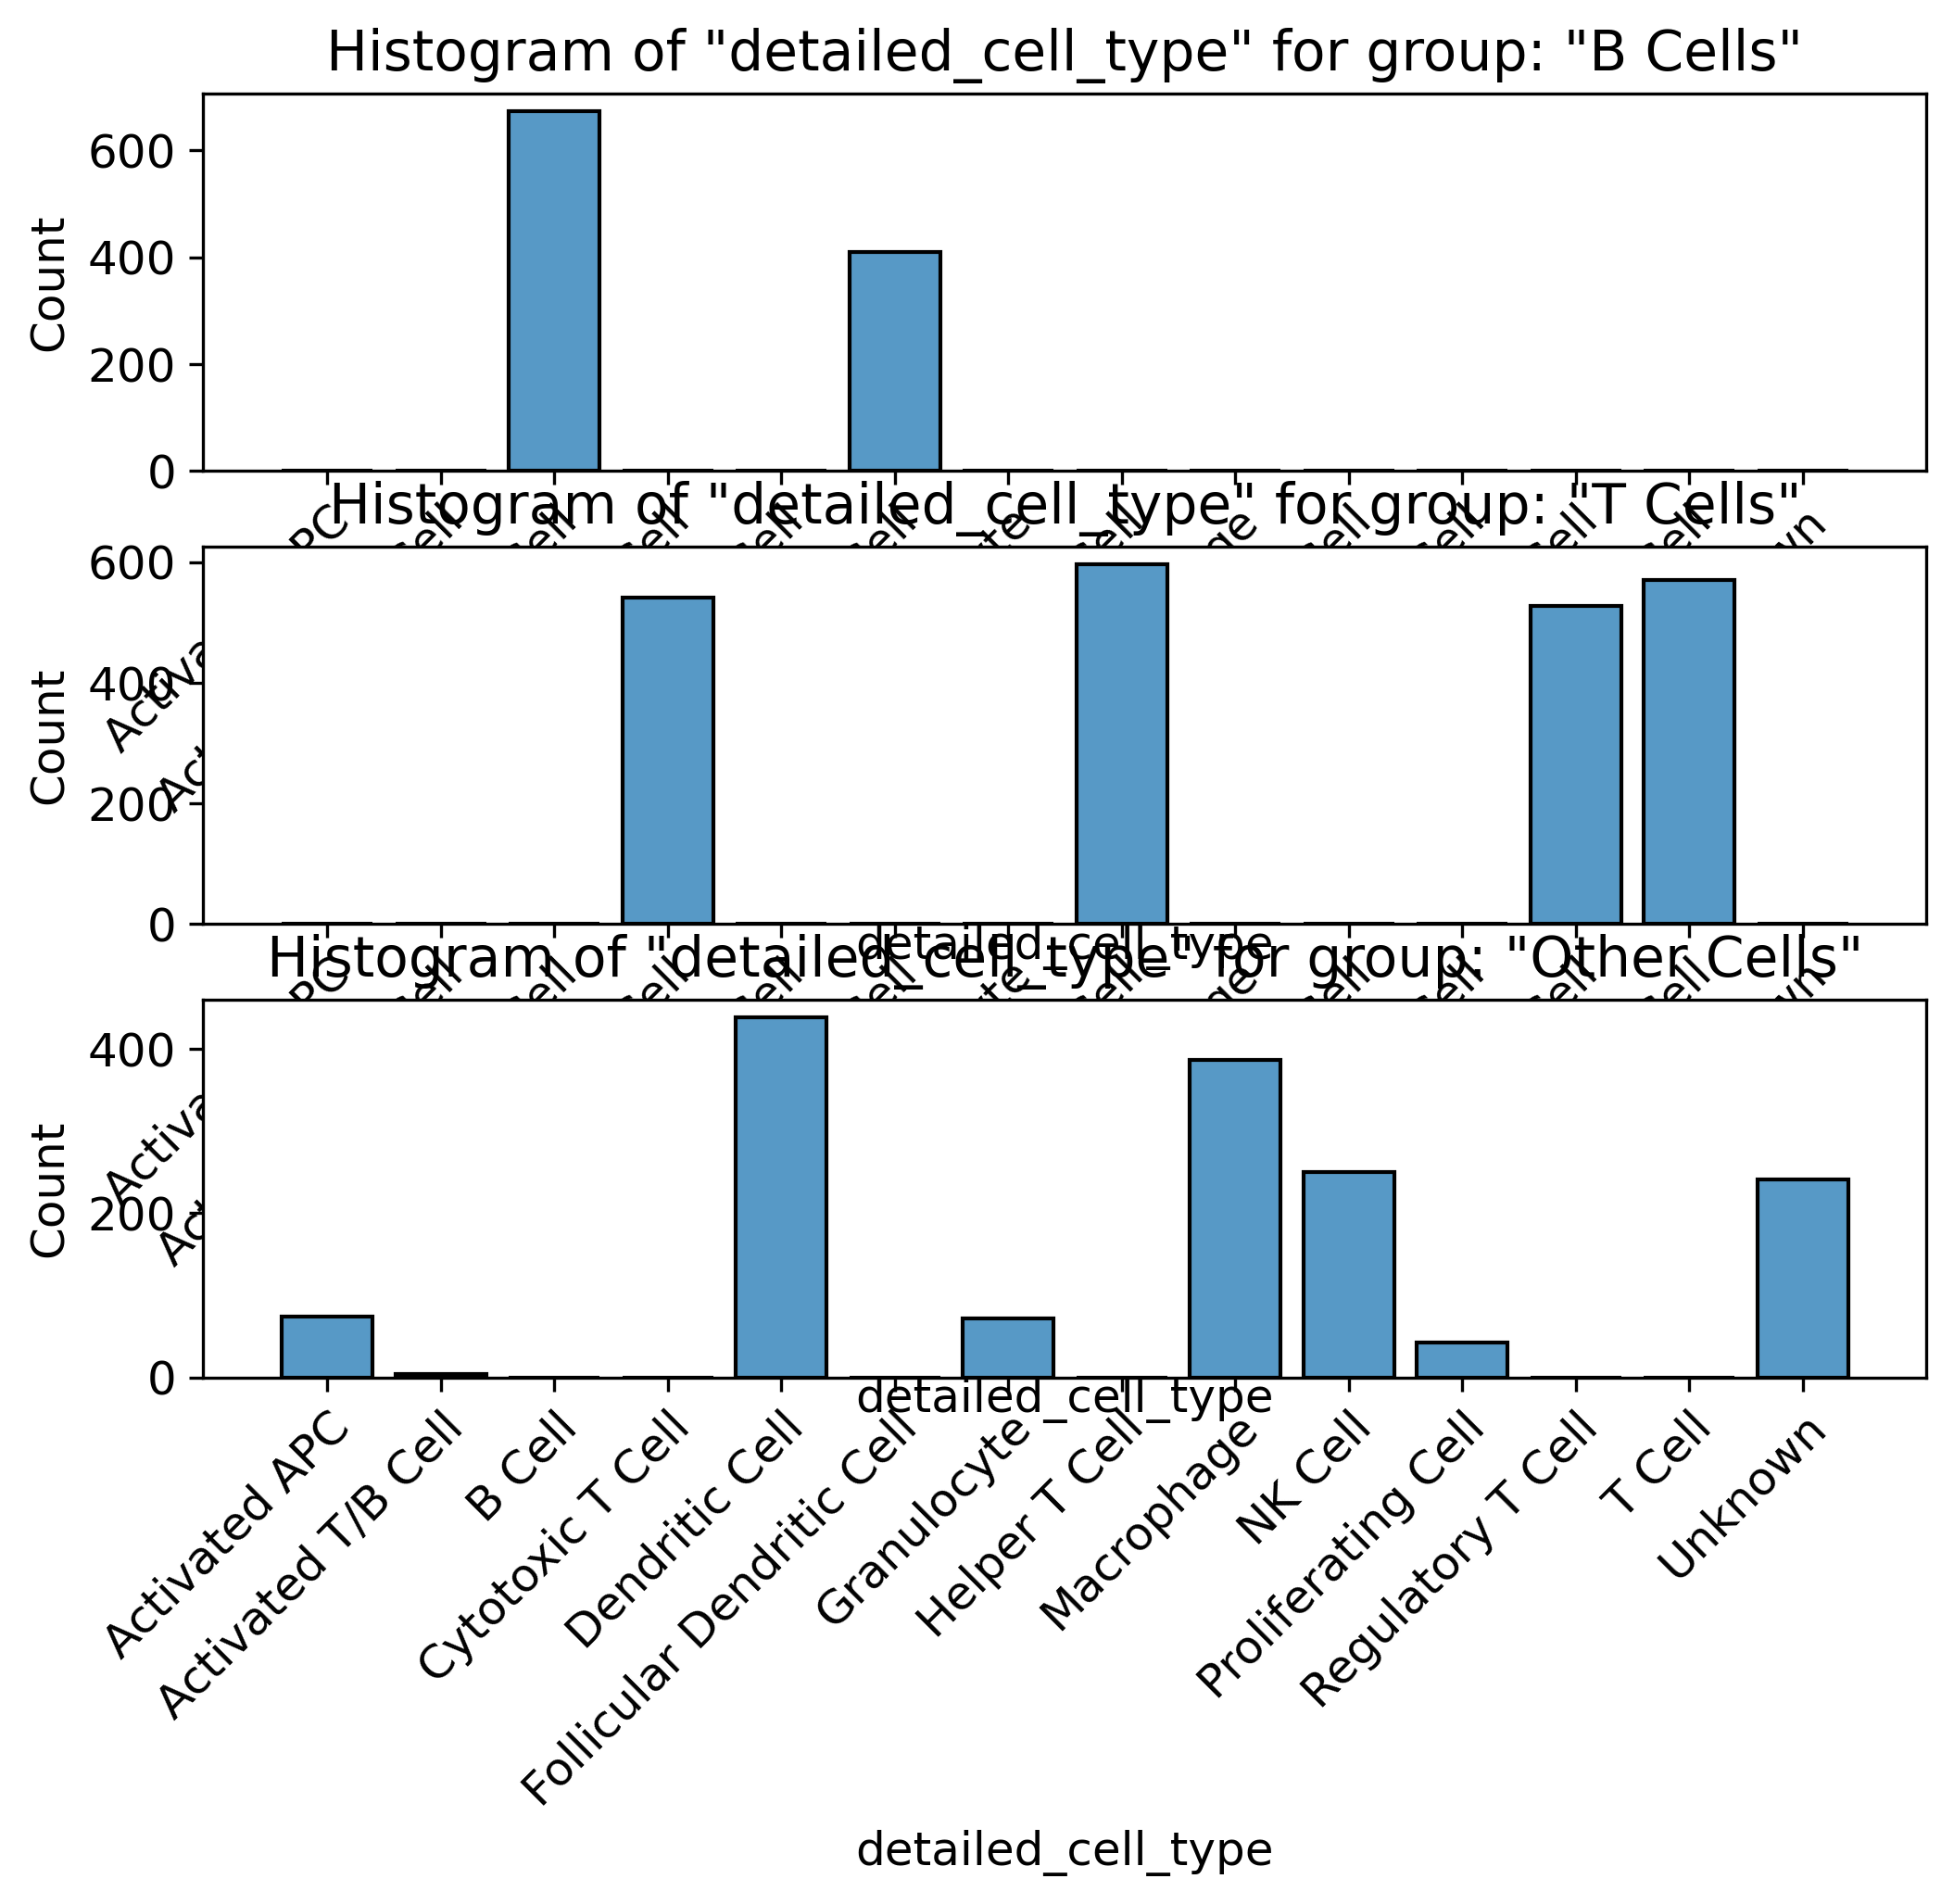

2026-04-19 22:28:45,759 - INFO - Returning figure and dataframe for in-memory use


In [8]:
params["Facet"] = False

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

- annotation="detailed_cell_type"->"CD20spatial_plot"
- group_by="broad_cell_type"
- together=False
- bins=15
- x_rotate=45->0
- histplot_by="Annotation"
- facet=False->True
- facet_ncol=2

2026-04-19 22:28:45,796 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:45,797 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:45,797 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.


Automatically calculated number of bins is: 33


2026-04-19 22:28:46,053 - INFO - Displaying top 10 rows of histogram dataframe:


         CD25         CD2         CD10       CD163         CD3D          CD5  \
0  581.581197  618.384615  1606.777778  509.324786   477.589744  1795.410256   
1  565.893204  442.291262  1539.398058  496.825243   484.902913  1793.932039   
2  666.475000  574.333333  1759.683333  548.050000   494.166667  1901.141667   
3  558.503356  408.577181  1557.738255  472.369127   347.093960  1772.805369   
4  562.000000  524.455090  1596.982036  482.065868   372.898204  1808.514970   
5  558.549419  536.395349  1500.401163  489.200581   665.761628  1770.860465   
6  599.720497  806.130435  1759.869565  499.621118   911.291926  1789.795031   
7  563.401575  713.960630  1450.149606  476.000000  1631.606299  1743.488189   
8  584.614841  658.671378  1525.837456  523.844523   819.522968  1771.459364   
9  585.398551  611.376812  1588.652174  519.594203   448.572464  1822.485507   

          CD30        ACTIN         CD45        CD206  ...         CD15  \
0  1084.051282  5382.076923  2983.239316  11

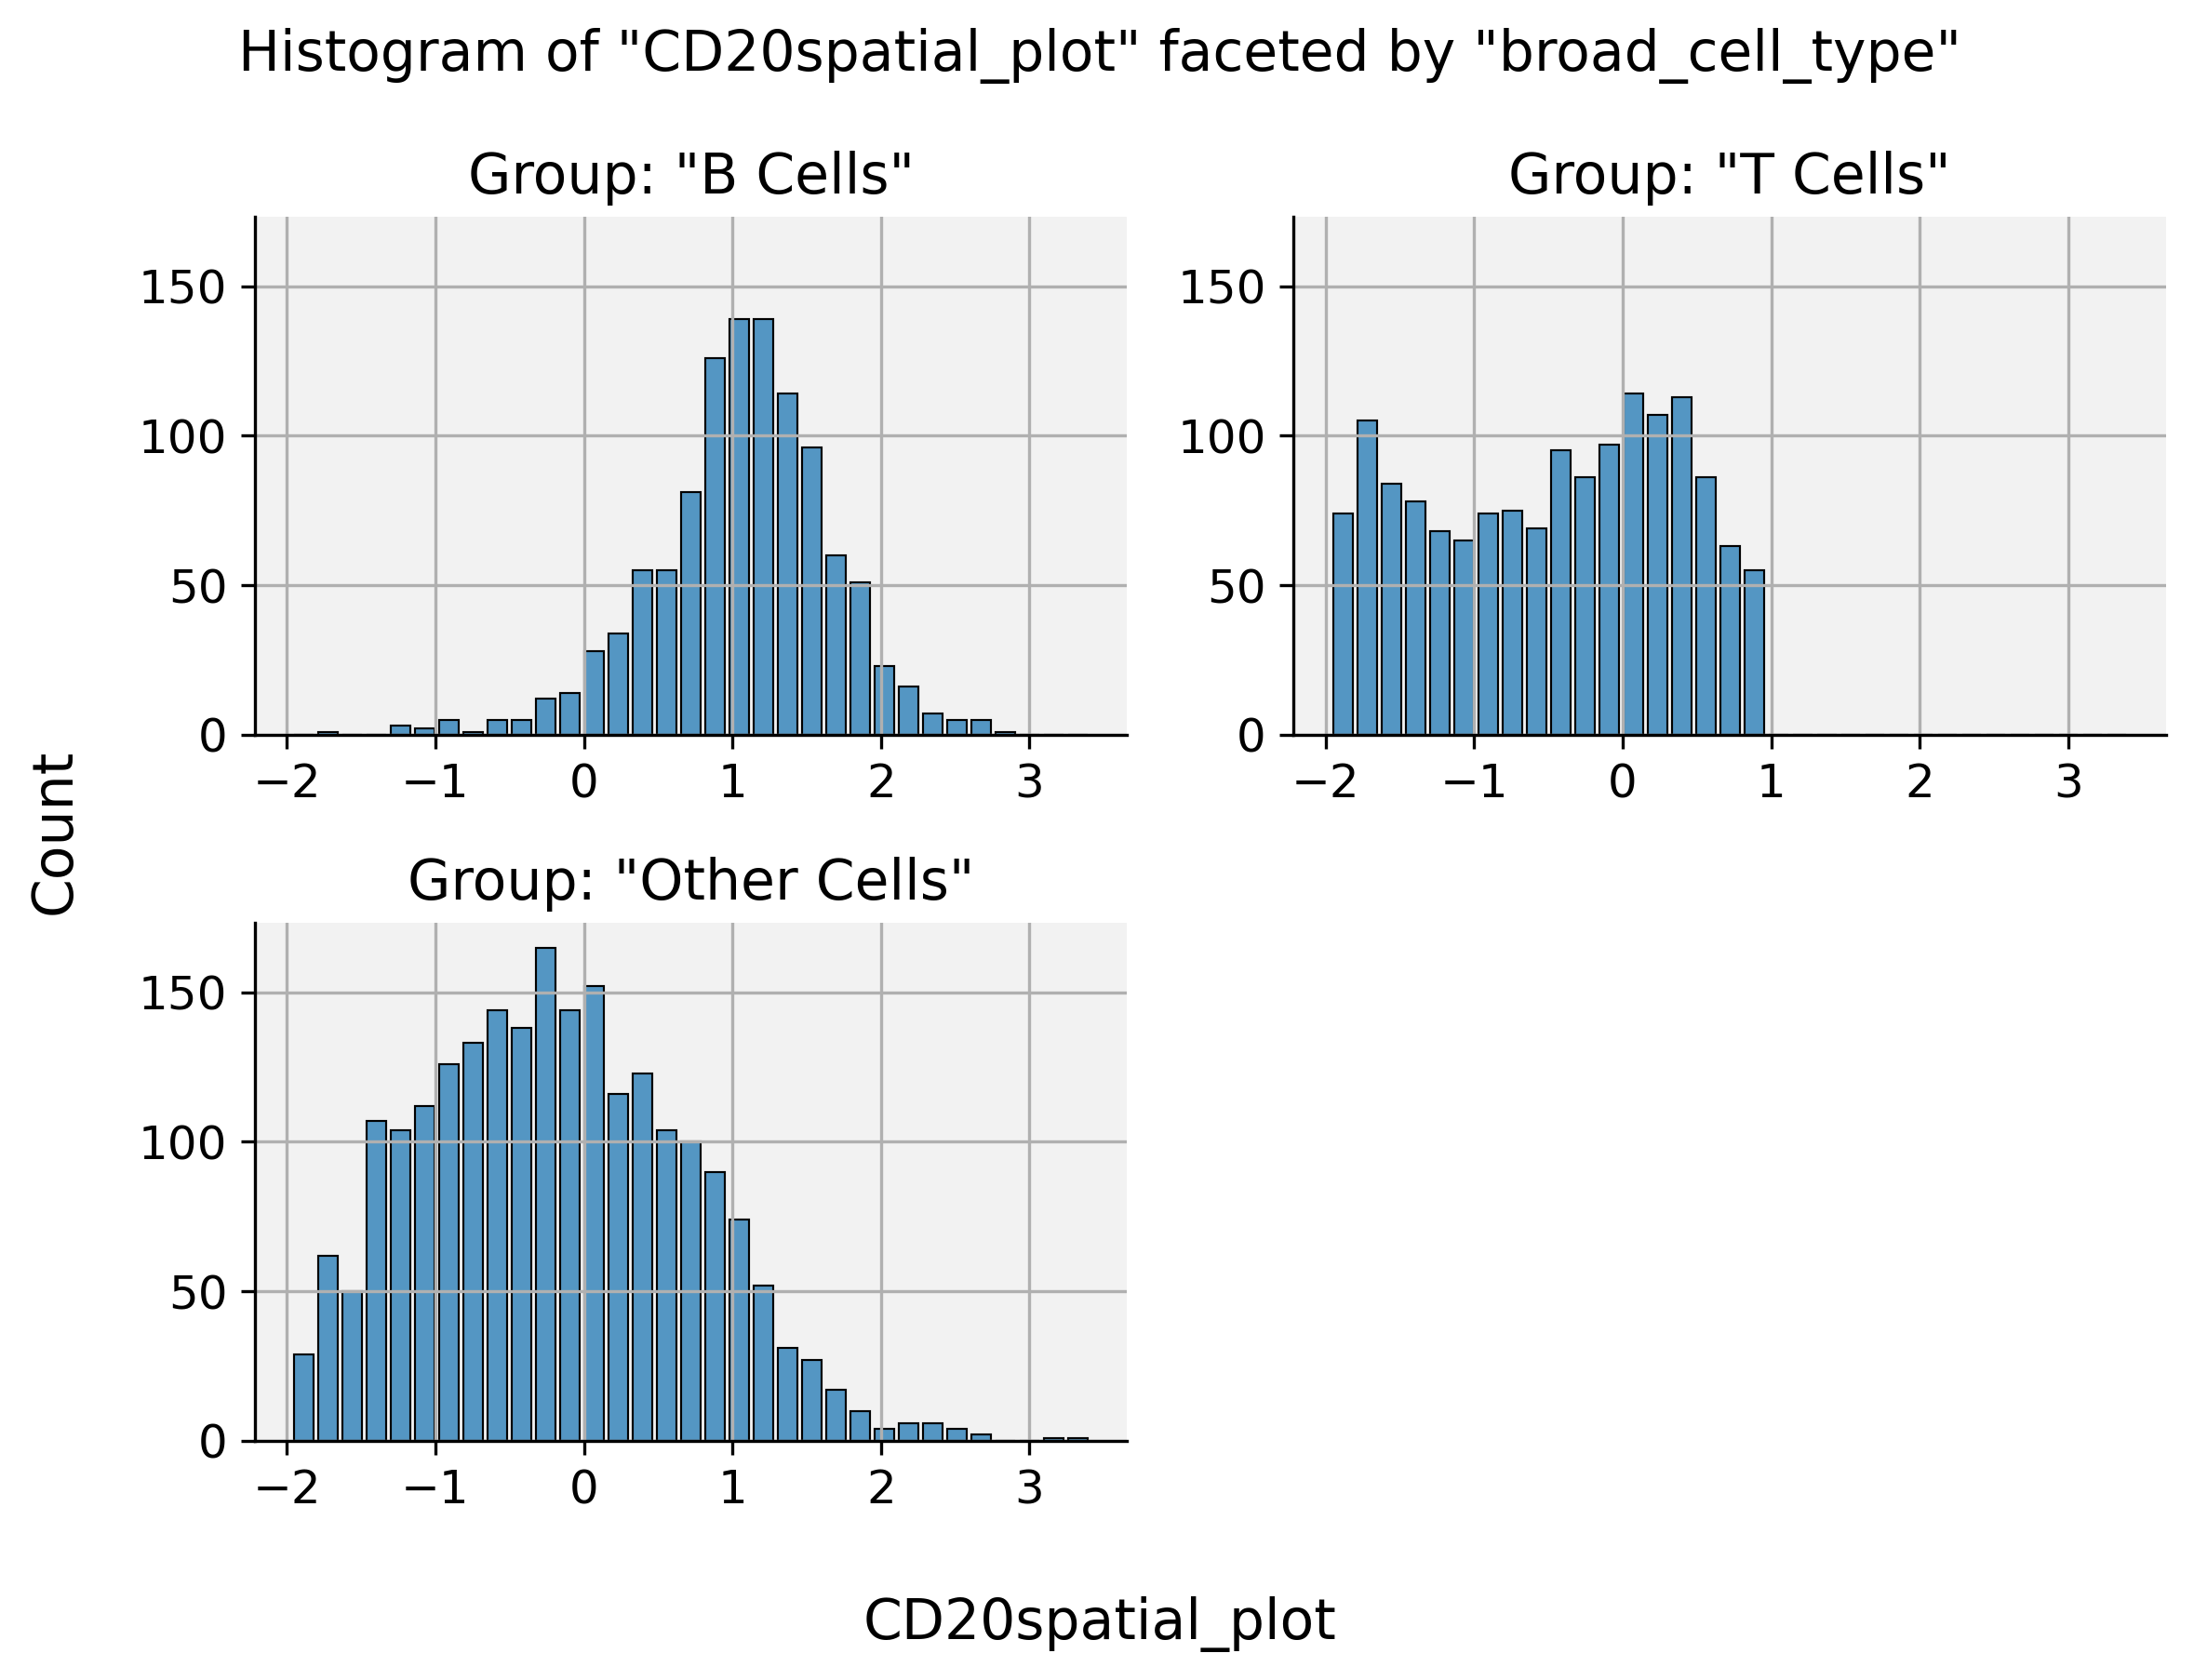

2026-04-19 22:28:46,221 - INFO - Returning figure and dataframe for in-memory use


In [9]:
params["Annotation"] = "CD20spatial_plot"
params["X_Axis_Label_Rotation"] = 0
params["Facet"] = True
params["Facet_Ncol"] = 2

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.6 Test facet_ncol

- annotation="CD20spatial_plot"
- group_by="broad_cell_type"
- together=False
- bins=15
- plot_by="Annotation"
- facet=True
- facet_ncol=2->3

2026-04-19 22:28:46,247 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:46,247 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:46,247 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.


Automatically calculated number of bins is: 33


2026-04-19 22:28:46,525 - INFO - Displaying top 10 rows of histogram dataframe:


         CD25         CD2         CD10       CD163         CD3D          CD5  \
0  581.581197  618.384615  1606.777778  509.324786   477.589744  1795.410256   
1  565.893204  442.291262  1539.398058  496.825243   484.902913  1793.932039   
2  666.475000  574.333333  1759.683333  548.050000   494.166667  1901.141667   
3  558.503356  408.577181  1557.738255  472.369127   347.093960  1772.805369   
4  562.000000  524.455090  1596.982036  482.065868   372.898204  1808.514970   
5  558.549419  536.395349  1500.401163  489.200581   665.761628  1770.860465   
6  599.720497  806.130435  1759.869565  499.621118   911.291926  1789.795031   
7  563.401575  713.960630  1450.149606  476.000000  1631.606299  1743.488189   
8  584.614841  658.671378  1525.837456  523.844523   819.522968  1771.459364   
9  585.398551  611.376812  1588.652174  519.594203   448.572464  1822.485507   

          CD30        ACTIN         CD45        CD206  ...         CD15  \
0  1084.051282  5382.076923  2983.239316  11

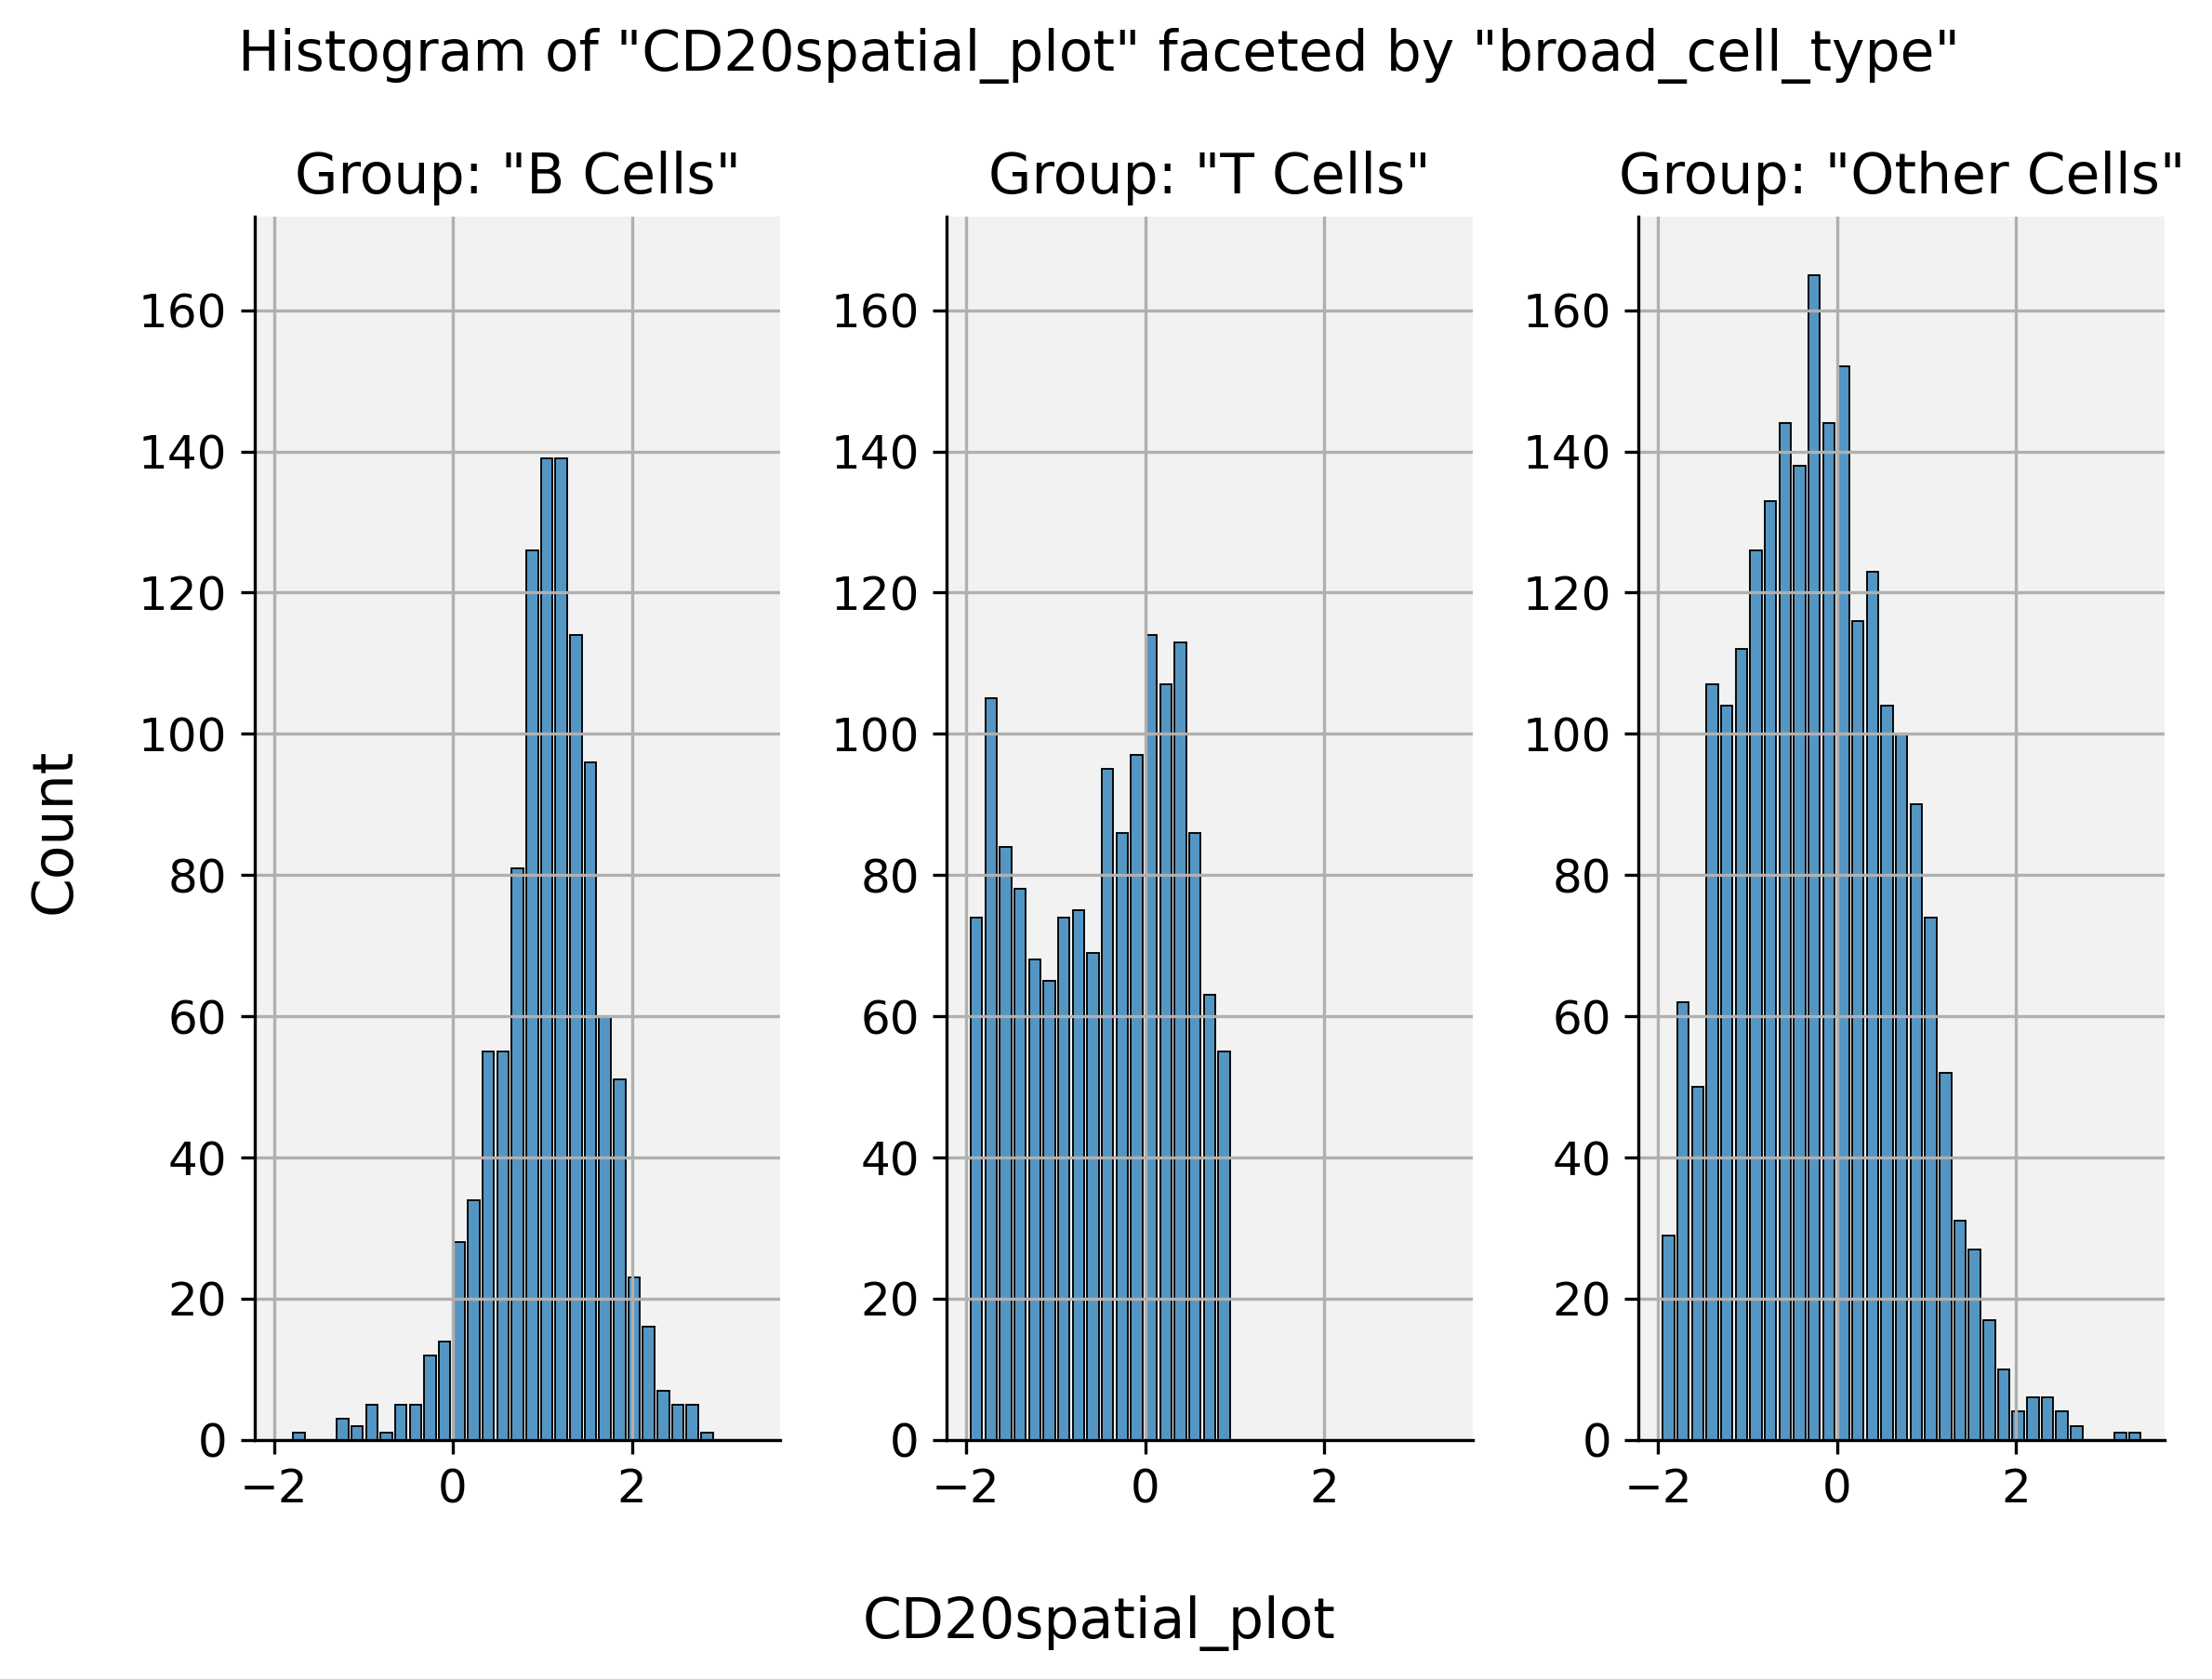

2026-04-19 22:28:46,704 - INFO - Returning figure and dataframe for in-memory use


In [10]:
params["Facet_Ncol"] = 3

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.7 Test fig_width and fig_height

- annotation="CD20spatial_plot"
- group_by="broad_cell_type"
- together=False
- fig_width=None(=8 by default)->10
- fig_height=None(=6 by default)->5
- bins=15
- histplot_by="Annotation"
- facet=True
- facet_ncol=3

2026-04-19 22:28:46,732 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:46,732 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:46,733 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.


Automatically calculated number of bins is: 33


2026-04-19 22:28:46,916 - INFO - Displaying top 10 rows of histogram dataframe:


         CD25         CD2         CD10       CD163         CD3D          CD5  \
0  581.581197  618.384615  1606.777778  509.324786   477.589744  1795.410256   
1  565.893204  442.291262  1539.398058  496.825243   484.902913  1793.932039   
2  666.475000  574.333333  1759.683333  548.050000   494.166667  1901.141667   
3  558.503356  408.577181  1557.738255  472.369127   347.093960  1772.805369   
4  562.000000  524.455090  1596.982036  482.065868   372.898204  1808.514970   
5  558.549419  536.395349  1500.401163  489.200581   665.761628  1770.860465   
6  599.720497  806.130435  1759.869565  499.621118   911.291926  1789.795031   
7  563.401575  713.960630  1450.149606  476.000000  1631.606299  1743.488189   
8  584.614841  658.671378  1525.837456  523.844523   819.522968  1771.459364   
9  585.398551  611.376812  1588.652174  519.594203   448.572464  1822.485507   

          CD30        ACTIN         CD45        CD206  ...         CD15  \
0  1084.051282  5382.076923  2983.239316  11

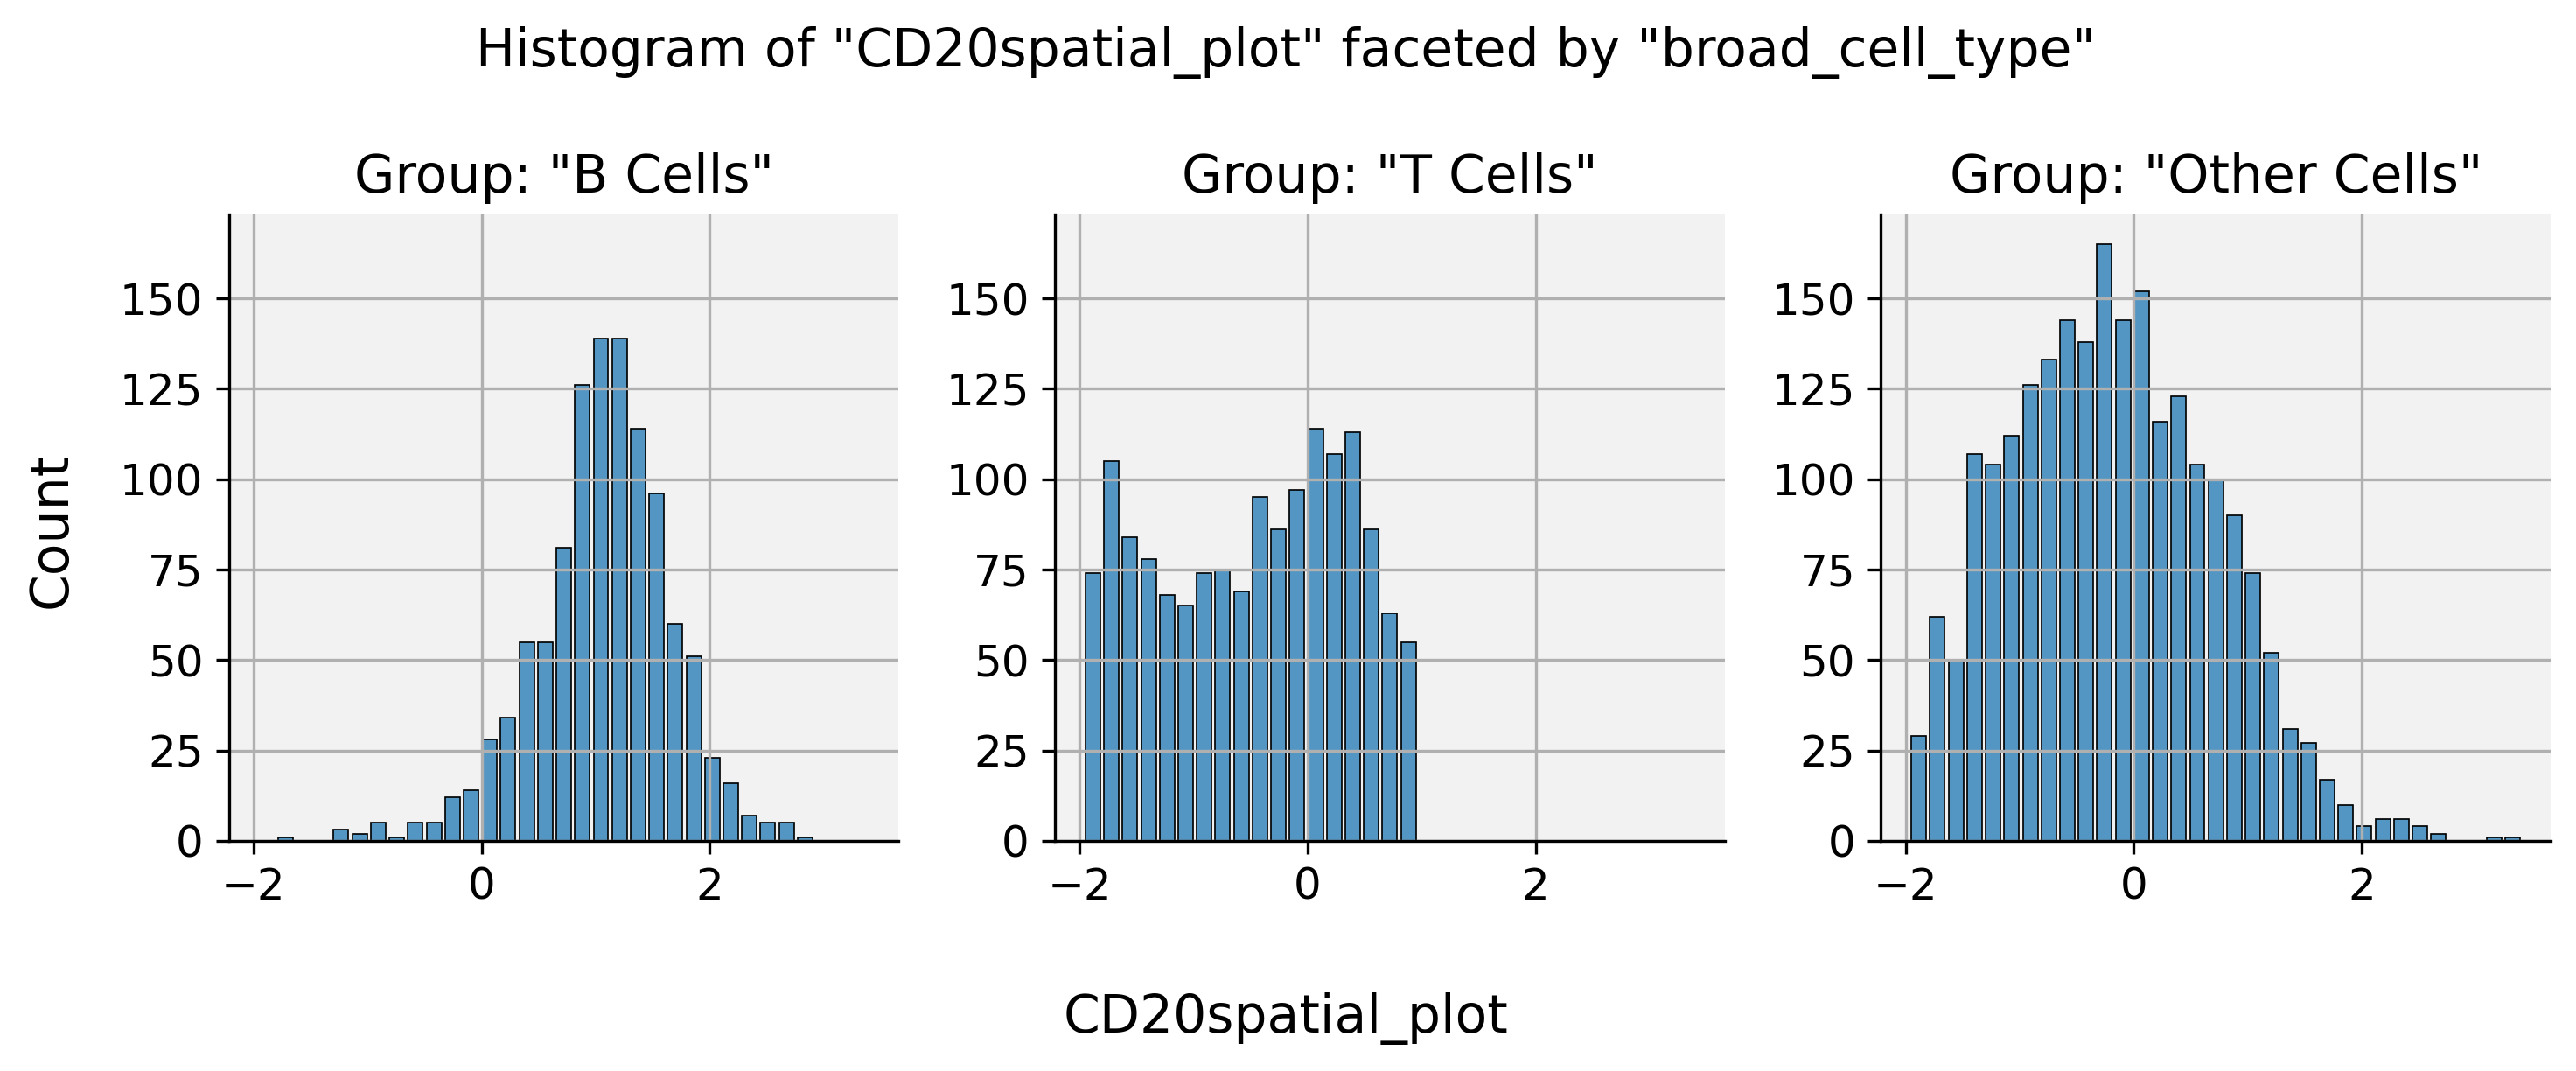

2026-04-19 22:28:47,076 - INFO - Returning figure and dataframe for in-memory use


In [11]:
params["Figure_Width"] = 10
params["Figure_Height"] = 4

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.8 Test stat

- annotation="CD20spatial_plot"
- group_by="broad_cell_type"
- together=False
- fig_width=10->None(=8 by default)
- fig_height=5->None(=6 by default)
- bins=15
- stat="count"->"percent"
- histplot_by="Annotation"
- facet=True
- facet_ncol=3->2

2026-04-19 22:28:47,104 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:47,104 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:47,104 - WARNING - Multiple should not be used when Together is False. Setting Multiple to 'dodge'.


Automatically calculated number of bins is: 33


2026-04-19 22:28:47,294 - INFO - Displaying top 10 rows of histogram dataframe:


         CD25         CD2         CD10       CD163         CD3D          CD5  \
0  581.581197  618.384615  1606.777778  509.324786   477.589744  1795.410256   
1  565.893204  442.291262  1539.398058  496.825243   484.902913  1793.932039   
2  666.475000  574.333333  1759.683333  548.050000   494.166667  1901.141667   
3  558.503356  408.577181  1557.738255  472.369127   347.093960  1772.805369   
4  562.000000  524.455090  1596.982036  482.065868   372.898204  1808.514970   
5  558.549419  536.395349  1500.401163  489.200581   665.761628  1770.860465   
6  599.720497  806.130435  1759.869565  499.621118   911.291926  1789.795031   
7  563.401575  713.960630  1450.149606  476.000000  1631.606299  1743.488189   
8  584.614841  658.671378  1525.837456  523.844523   819.522968  1771.459364   
9  585.398551  611.376812  1588.652174  519.594203   448.572464  1822.485507   

          CD30        ACTIN         CD45        CD206  ...         CD15  \
0  1084.051282  5382.076923  2983.239316  11

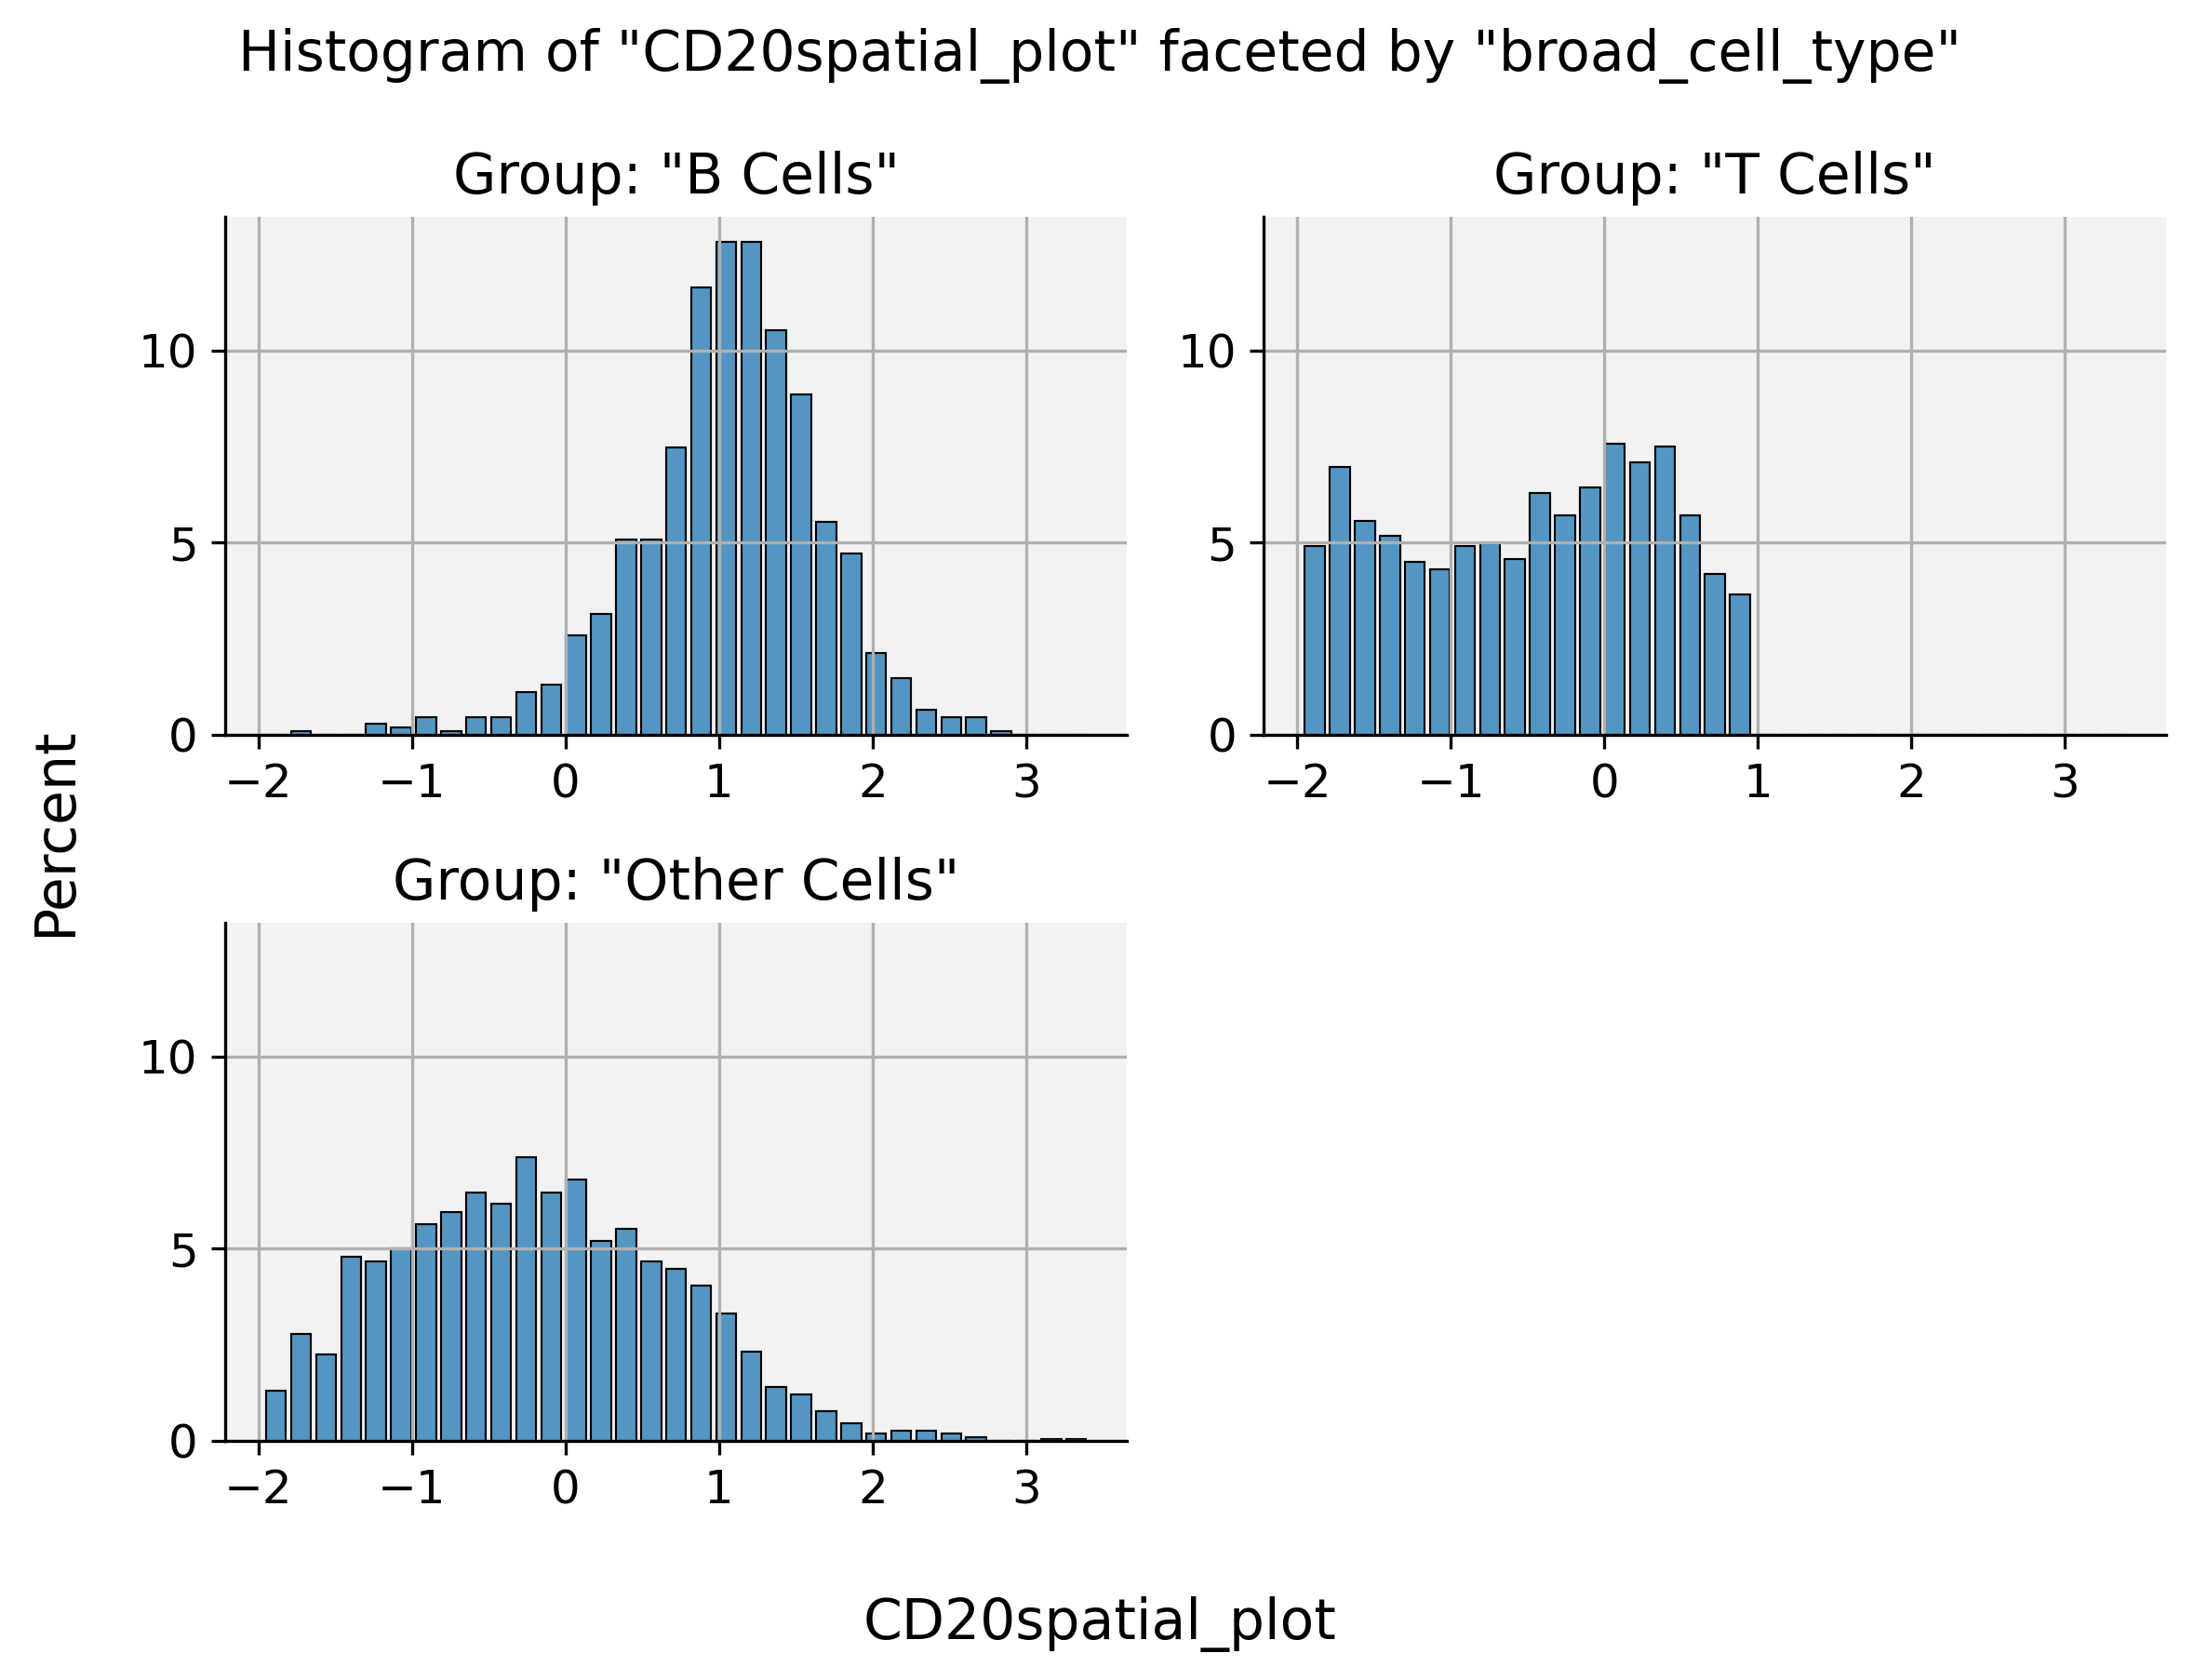

2026-04-19 22:28:47,463 - INFO - Returning figure and dataframe for in-memory use


In [12]:
params.pop("Figure_Width")
params.pop("Figure_Height")
params["Facet_Ncol"] = 2
params["Stat"] = "percent"

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

### Y.9 Test multiple, element in together mode

- annotation="CD20spatial_plot"
- together=False->True
- bins=15
- multiple=None("dodge")->"stack"
- element=None("bars")->"poly"
- stat="percent"
- histplot_by="Annotation"
- facet=True->False
- facet_ncol=2

2026-04-19 22:28:47,491 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:47,492 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.


Automatically calculated number of bins is: 33


2026-04-19 22:28:47,541 - INFO - Displaying top 10 rows of histogram dataframe:


   count  bin_left  bin_right  bin_center broad_cell_type
0      0 -1.965806  -1.802989   -1.884397         B Cells
1      1 -1.802989  -1.640173   -1.721581         B Cells
2      0 -1.640173  -1.477356   -1.558764         B Cells
3      0 -1.477356  -1.314540   -1.395948         B Cells
4      3 -1.314540  -1.151723   -1.233131         B Cells
5      2 -1.151723  -0.988907   -1.070315         B Cells
6      5 -0.988907  -0.826090   -0.907499         B Cells
7      1 -0.826090  -0.663274   -0.744682         B Cells
8      5 -0.663274  -0.500457   -0.581866         B Cells
9      5 -0.500457  -0.337641   -0.419049         B Cells


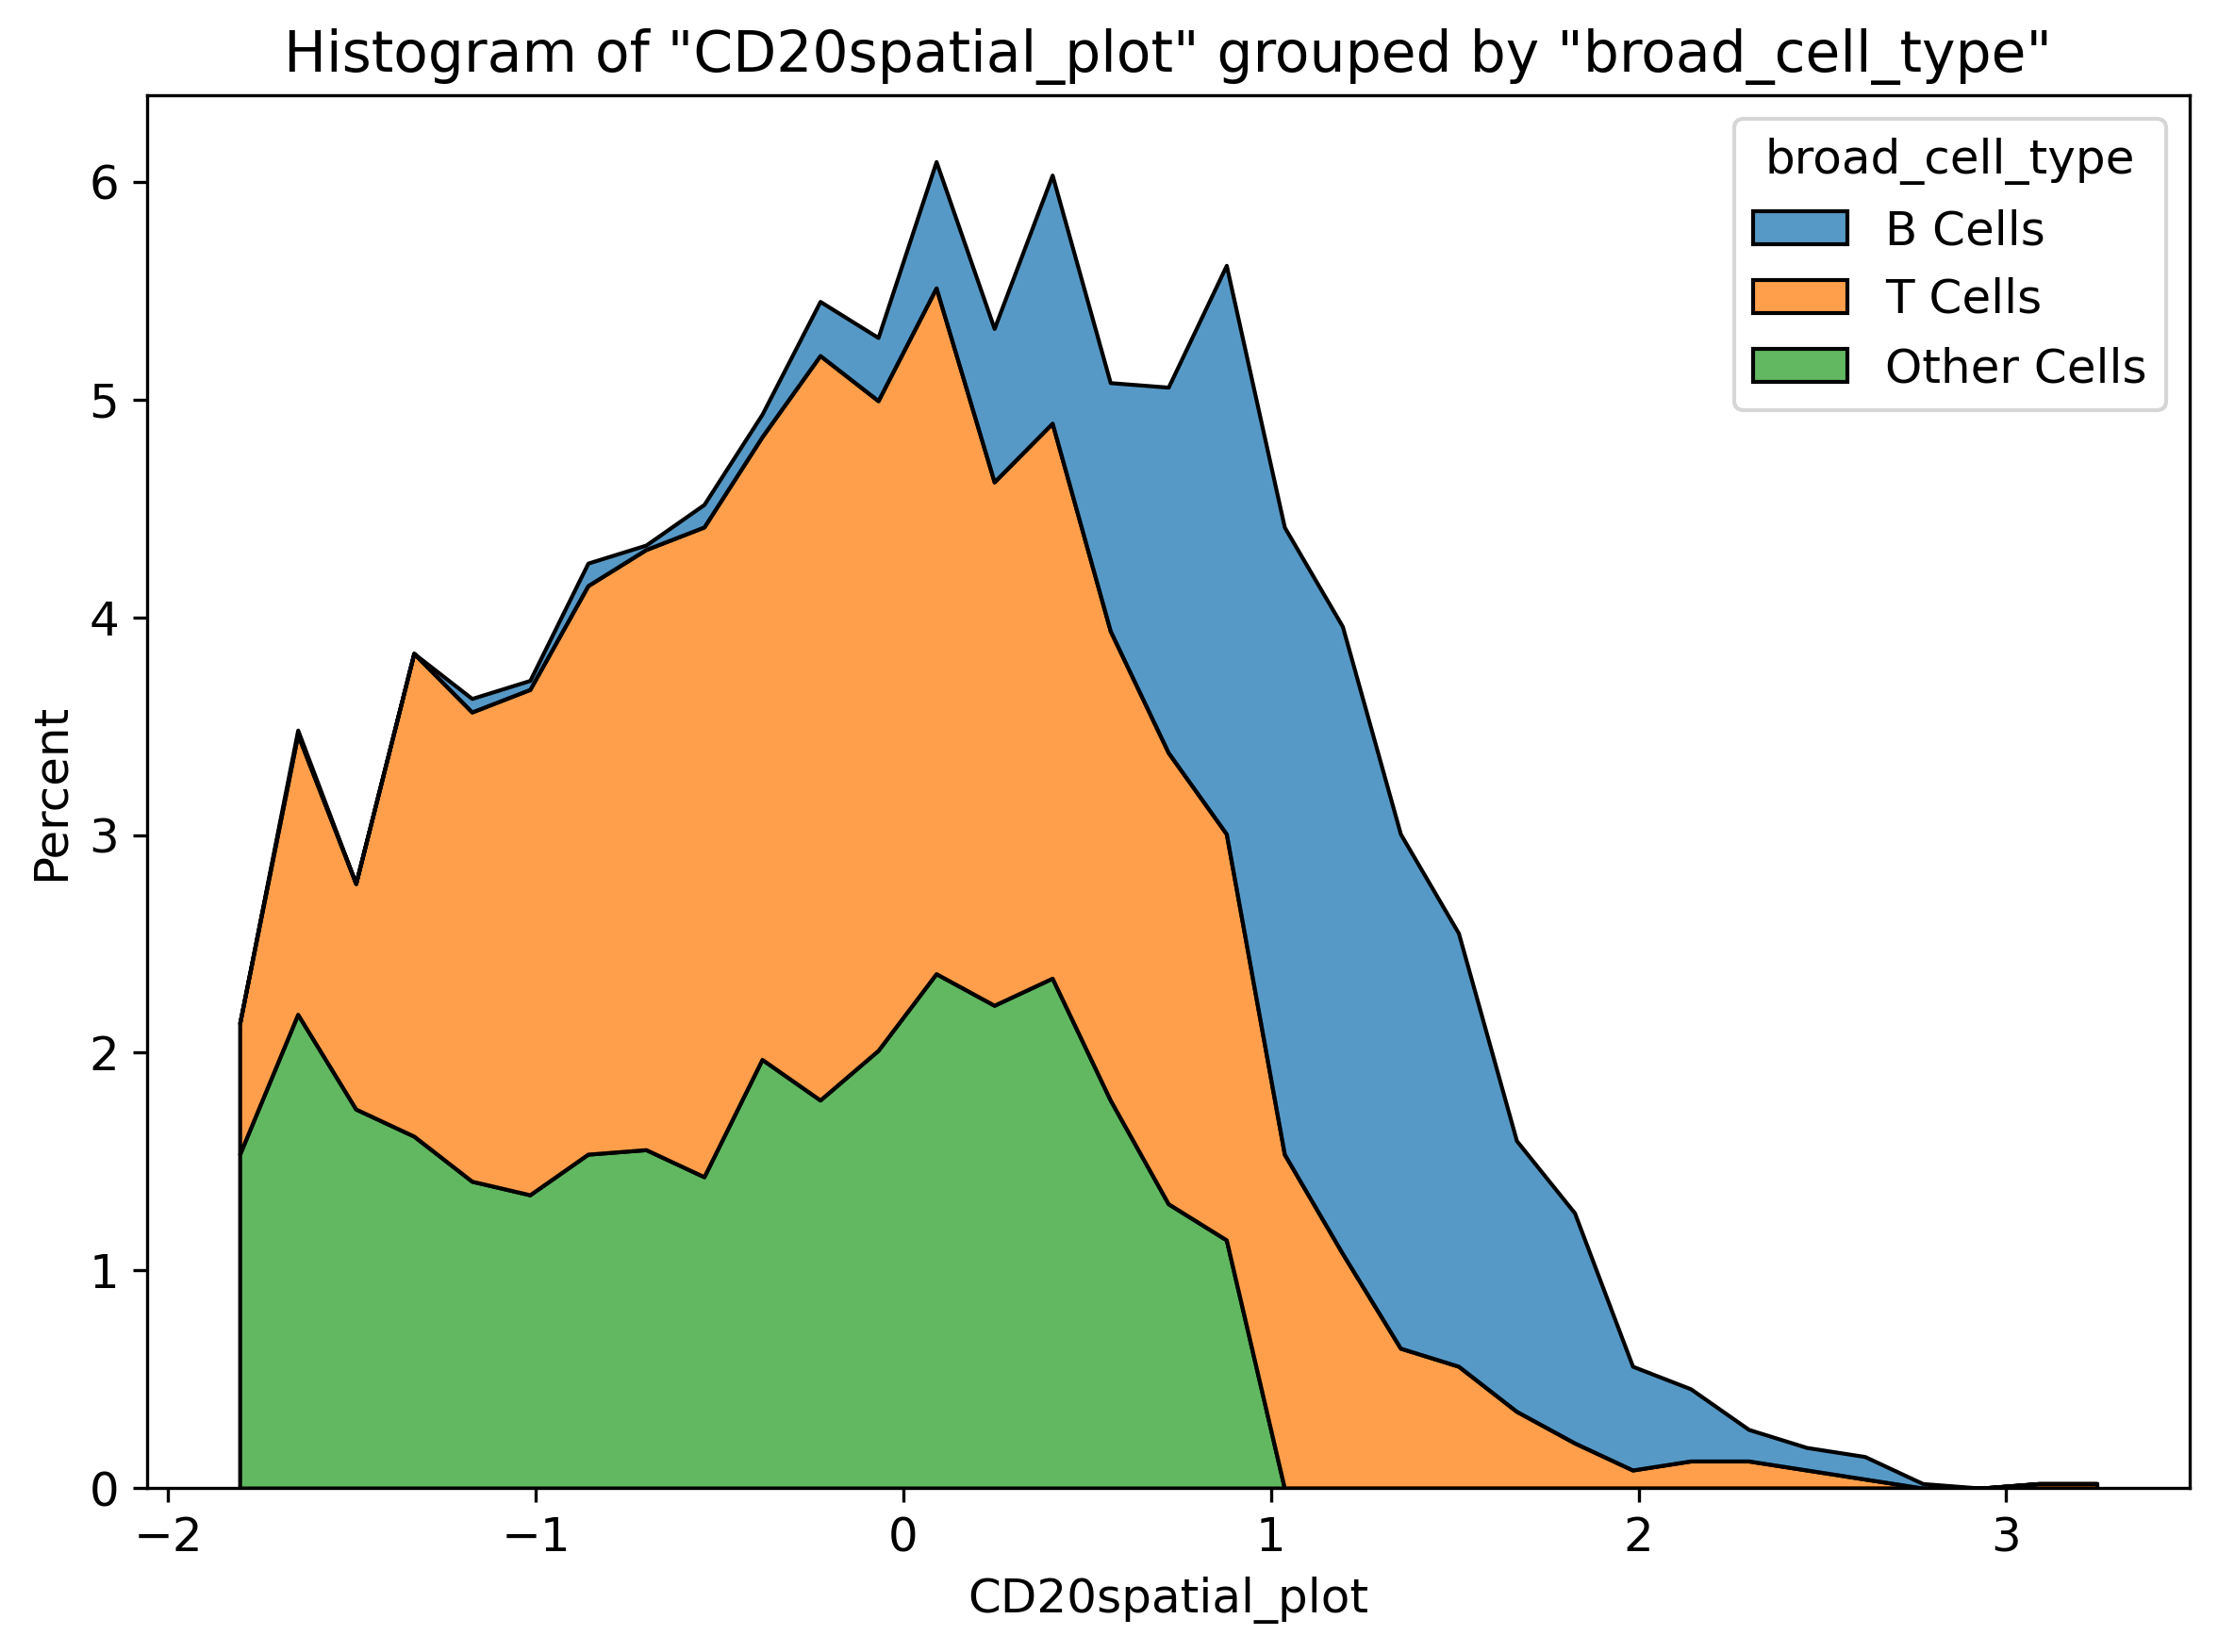

2026-04-19 22:28:47,712 - INFO - Returning figure and dataframe for in-memory use


bins= 15


In [13]:
params["Multiple"] = "stack"
params["Element"] = "poly"
params["Together"] = True
params["Facet"] = False

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

print("bins=", params["Bins"])

### Y.10 Test layout issue after scimap is imported

import scimap to see layout changes

In [14]:
import scimap as sm
import matplotlib.pyplot as plt
print(plt.rcParams["axes.grid"])

Running SCIMAP  2.3.6


/Users/bojohnzhang/miniconda3/envs/spac/lib/python3.9/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



False


Now rerun the previous plot

2026-04-19 22:28:52,272 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:52,273 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:52,337 - INFO - Displaying top 10 rows of histogram dataframe:


Automatically calculated number of bins is: 33
   count  bin_left  bin_right  bin_center broad_cell_type
0      0 -1.965806  -1.802989   -1.884397         B Cells
1      1 -1.802989  -1.640173   -1.721581         B Cells
2      0 -1.640173  -1.477356   -1.558764         B Cells
3      0 -1.477356  -1.314540   -1.395948         B Cells
4      3 -1.314540  -1.151723   -1.233131         B Cells
5      2 -1.151723  -0.988907   -1.070315         B Cells
6      5 -0.988907  -0.826090   -0.907499         B Cells
7      1 -0.826090  -0.663274   -0.744682         B Cells
8      5 -0.663274  -0.500457   -0.581866         B Cells
9      5 -0.500457  -0.337641   -0.419049         B Cells


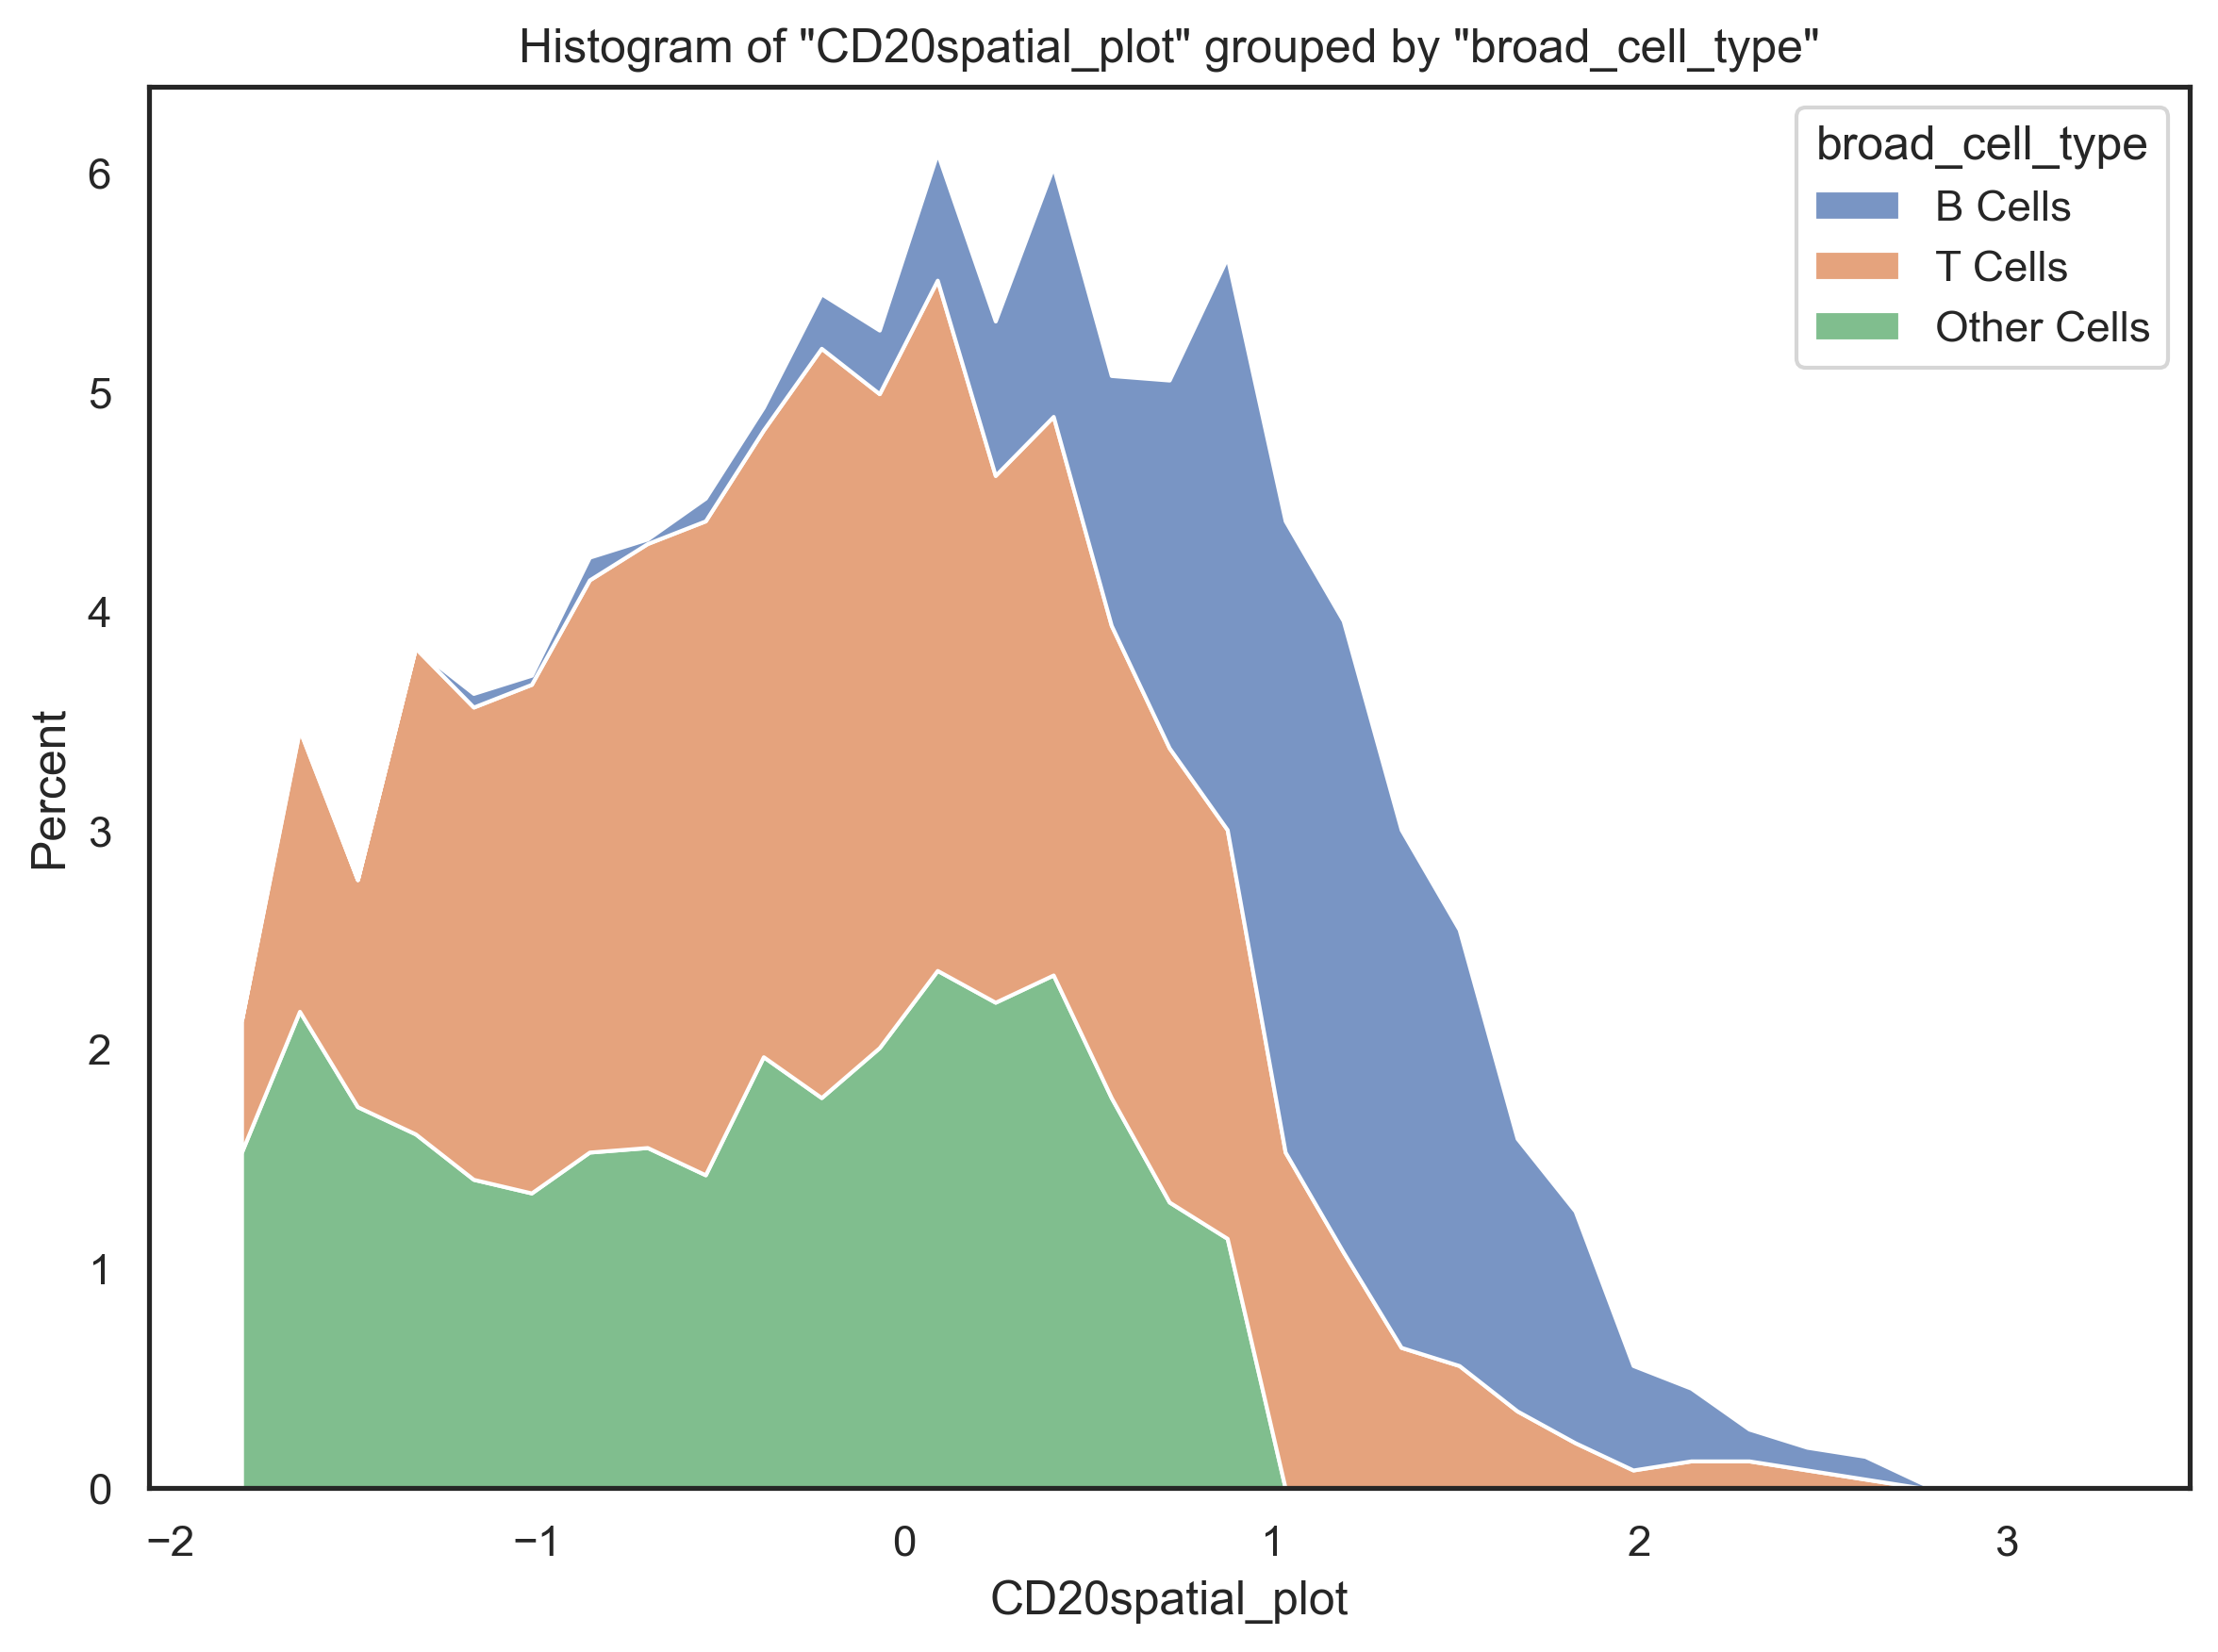

2026-04-19 22:28:52,529 - INFO - Returning figure and dataframe for in-memory use


In [15]:
result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

Now reset plt.rcParams

2026-04-19 22:28:52,572 - WARNING - Take X log should only apply to feature. Setting Take X Log to False.
2026-04-19 22:28:52,573 - WARNING - Bin number should only apply to feature. Setting bin number calculation to auto.
2026-04-19 22:28:52,632 - INFO - Displaying top 10 rows of histogram dataframe:


Automatically calculated number of bins is: 33
   count  bin_left  bin_right  bin_center broad_cell_type
0      0 -1.965806  -1.802989   -1.884397         B Cells
1      1 -1.802989  -1.640173   -1.721581         B Cells
2      0 -1.640173  -1.477356   -1.558764         B Cells
3      0 -1.477356  -1.314540   -1.395948         B Cells
4      3 -1.314540  -1.151723   -1.233131         B Cells
5      2 -1.151723  -0.988907   -1.070315         B Cells
6      5 -0.988907  -0.826090   -0.907499         B Cells
7      1 -0.826090  -0.663274   -0.744682         B Cells
8      5 -0.663274  -0.500457   -0.581866         B Cells
9      5 -0.500457  -0.337641   -0.419049         B Cells


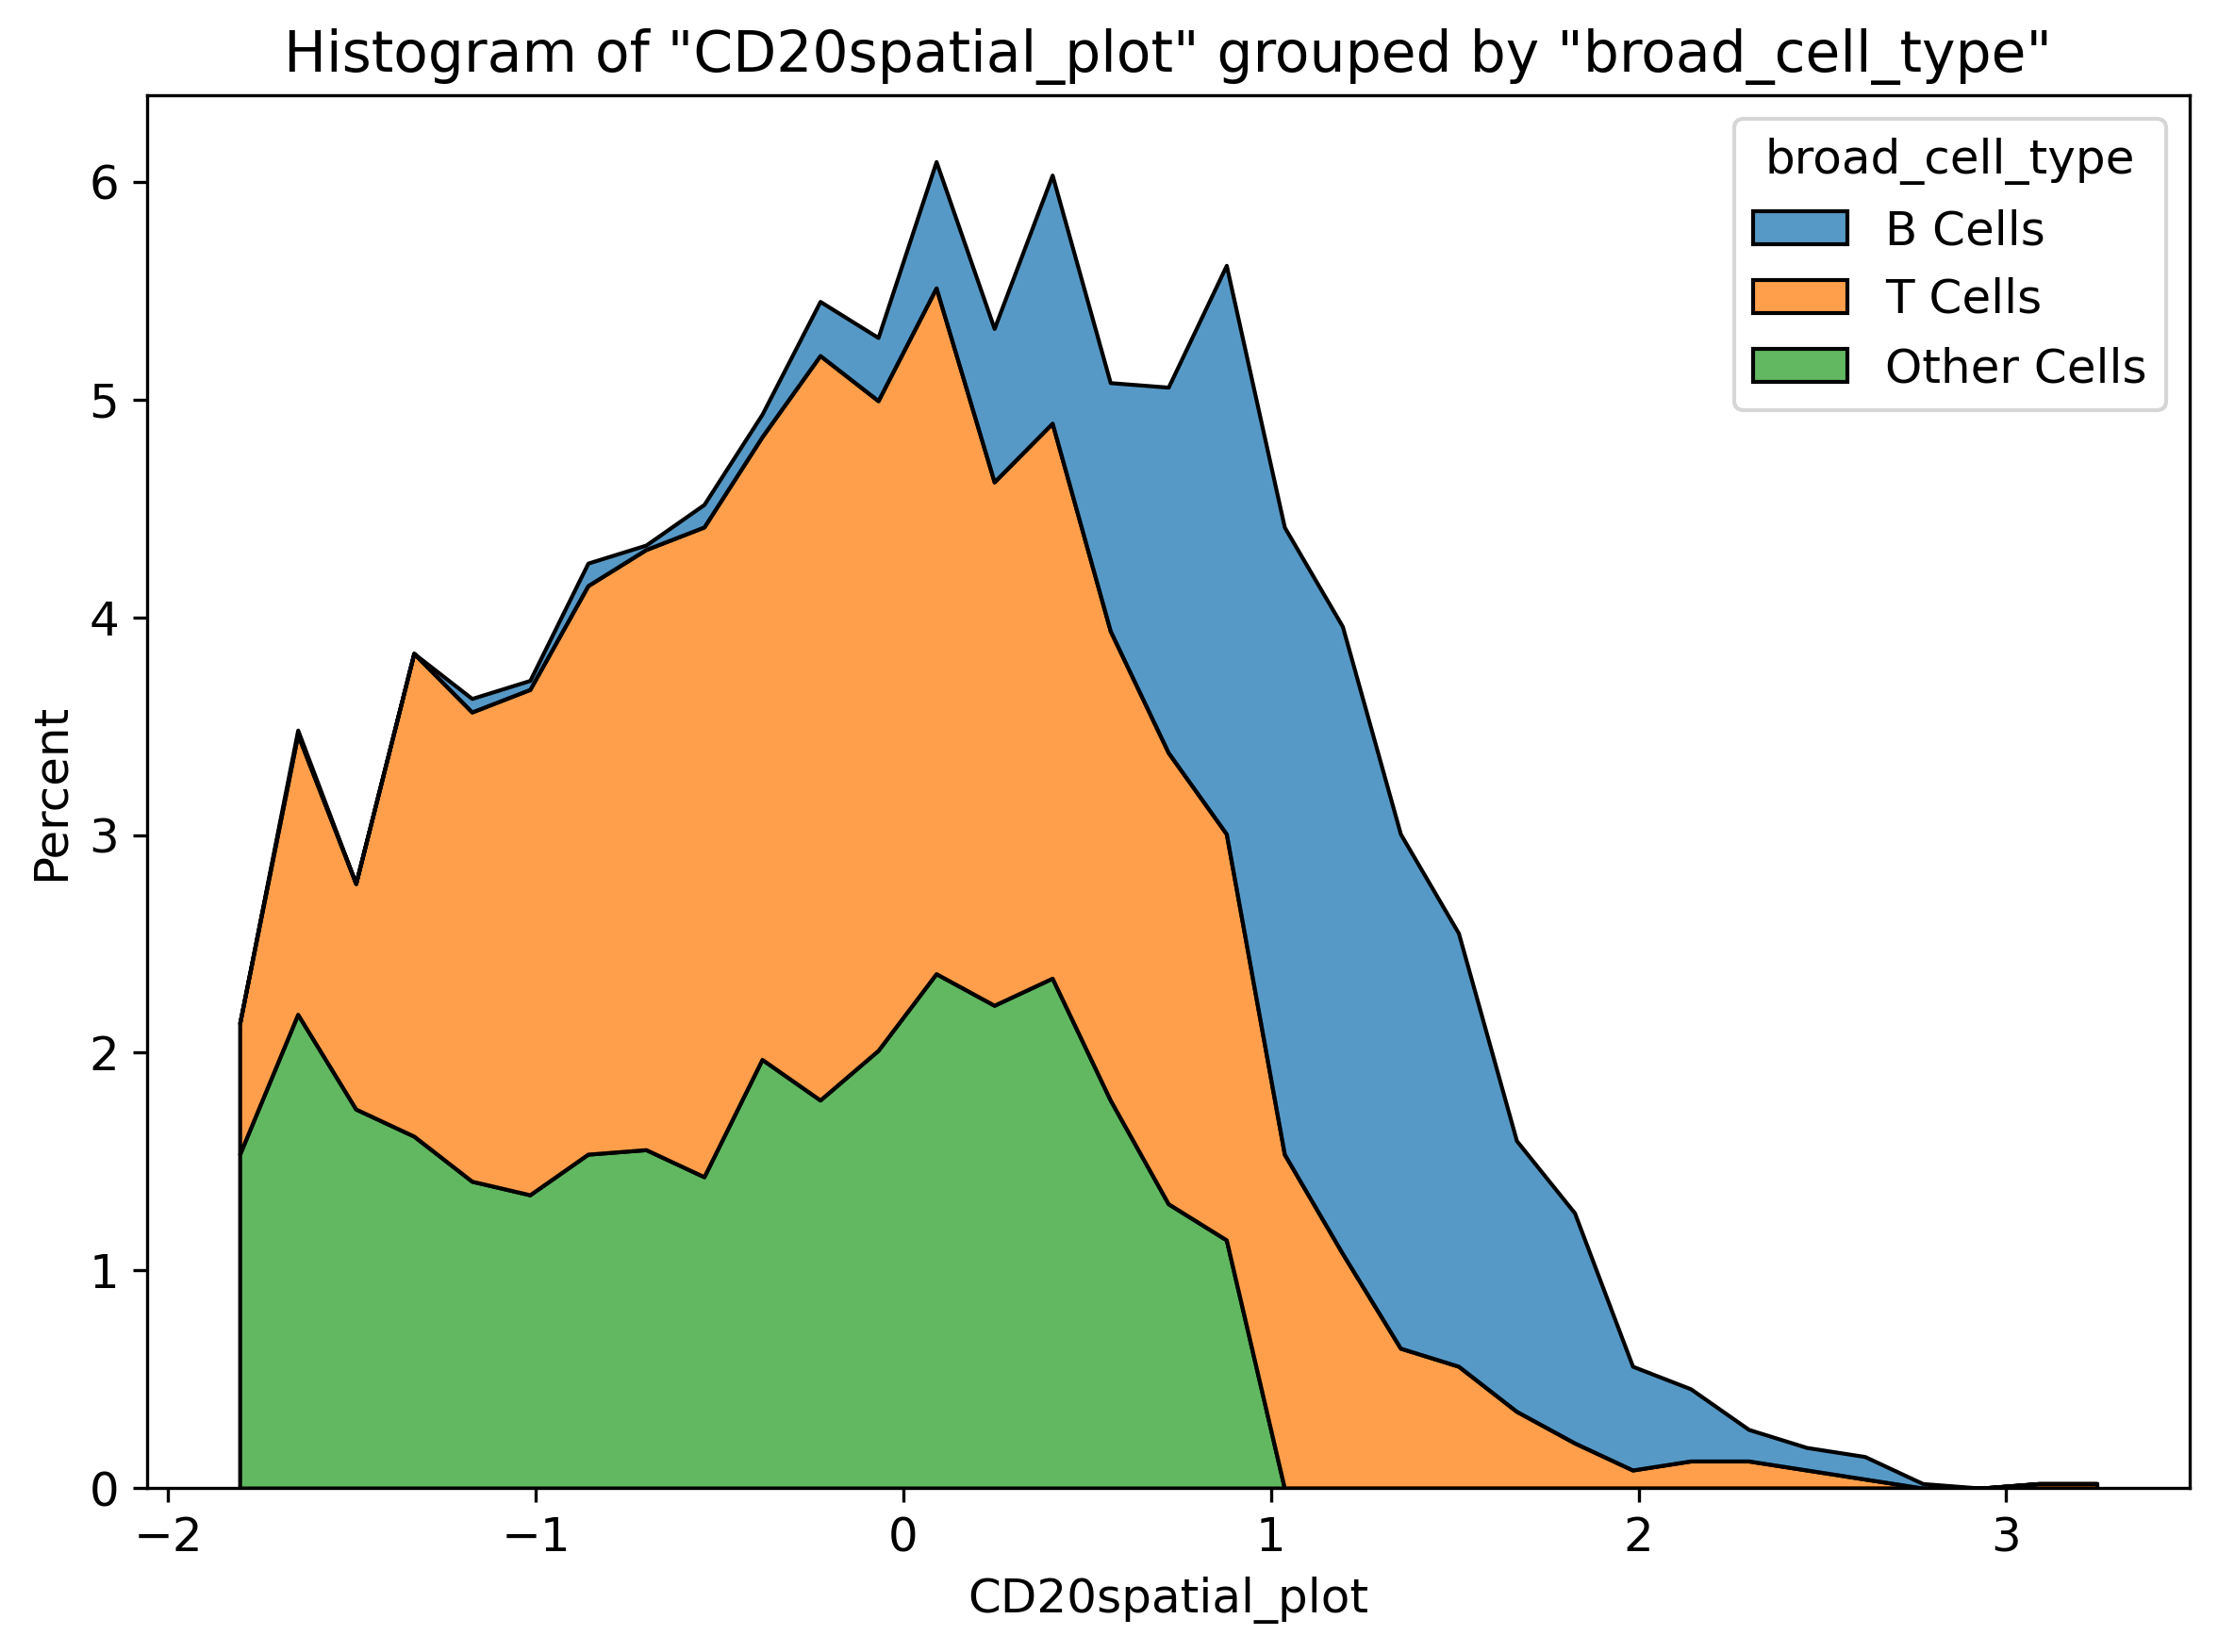

2026-04-19 22:28:52,795 - INFO - Returning figure and dataframe for in-memory use


In [16]:
plt.rcdefaults()

result = run_from_json(
    json_path=params,
    save_to_disk=False,
    show_plot=True
)

**Be careful when importing modules like scimap!**

## Environment

In [17]:
import os
import socket

print(f"I am running on: {socket.gethostname()}")
print(f"My process ID is: {os.getpid()}")

I am running on: Bojohns-MacBook-Air.local
My process ID is: 40161
